# Incremental Warehouse

## "Run it twice and nothing changes. Break the input and nothing publishes."

**Standalone notebook.** It generates its own shop, defines every function it
uses and writes nothing to disk. The warehouse is DuckDB in memory and the raw
lake is a dictionary of Arrow tables. The repo keeps the same partitions as
Parquet files. Nothing here imports from the project package.

### What you build

An incremental pipeline over an OLTP database that keeps changing. It extracts
only what changed, lands it as raw partitions, builds a type 2 dimension and
partitioned facts in DuckDB, runs checks as gating stages, and publishes all or
nothing. A small DAG runner in the notebook plays the part of Airflow.

### Why the source is generated

The shop is simulated for 30 days, so the notebook knows the true state of every
order on every day. Two failures are planted at counted sizes. **Late commits**
are changes stamped before midnight that only become visible the next day.
**Hard deletes** are orders that vanish from the source. Because the truth is
written down separately, each naive pipeline gets a measured error, not an
opinion. Only the scorer reads the truth.

In [1]:
# ============================================================================
# 0.1  Install
# ----------------------------------------------------------------------------
# In   : nothing
# Out  : duckdb and pyarrow if the runtime lacks them
# Note : Colab and Kaggle already have pandas, matplotlib, Jinja2 and
#        PyYAML.
# ============================================================================
%pip install -q duckdb pyarrow

Note: you may need to restart the kernel to use updated packages.


In [2]:
# ============================================================================
# 0.2  Imports and chart style
# ----------------------------------------------------------------------------
# In   : nothing
# Out  : plt, style(), palette
# Note : One palette for every chart. The first three slots are colourblind
#        safe.
# ============================================================================
import json
import time

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker
import pandas as pd
import yaml

pd.set_option("display.width", 170, "display.max_columns", 30, "display.max_colwidth", 80)

BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
SURFACE, INK, INK2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#b8b7b2"
mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": MUTED, "axes.linewidth": 0.8, "axes.spines.top": False,
    "axes.spines.right": False, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "text.color": INK, "xtick.color": INK2, "ytick.color": INK2, "xtick.labelsize": 9,
    "ytick.labelsize": 9, "axes.labelsize": 10, "grid.color": "#e8e7e3",
    "grid.linewidth": 0.8, "legend.frameon": False, "legend.fontsize": 9,
    "lines.linewidth": 2, "figure.dpi": 110, "font.size": 10,
})


def style(ax, title, sub=None, xlabel="", ylabel="", money=True):
    ax.set_title(title, pad=22 if sub else 12)
    if sub:
        ax.text(0, 1.04, sub, transform=ax.transAxes, fontsize=9.5, color=INK2, va="bottom")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.9, zorder=0)
    ax.set_axisbelow(True)
    if money:
        ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))
    return ax


def usd(cents):
    sign = "-" if cents < 0 else ""
    cents = abs(int(cents))
    return f"{sign}${cents // 100:,}.{cents % 100:02d}"


print("ready")

ready


In [3]:
# ============================================================================
# 0.3  Configuration
# ----------------------------------------------------------------------------
# In   : nothing
# Out  : CFG
# Note : The same conf/config.yaml the repo uses, embedded as text. Every
#        size and rate lives here.
# ============================================================================
CONFIG_YAML = r'''
# Every number the project uses lives here. Change the seed and every count in
# the README changes with it, so the tests pin the numbers for seed 42 only.
seed: 42

source:
  start_date: "2025-06-02"        # logical date of day 1
  days: 30
  initial_customers: 300          # created on day 1
  new_customers_per_day: [3, 8]   # inclusive range, from day 2
  regions: [NA, EU, APAC, LATAM]
  orders_per_day: [50, 70]        # inclusive range
  lines_per_order: [1, 4]
  quantity: [1, 5]
  sku_count: 40
  sku_price_cents: [499, 9999]
  # Daily chance that an open order moves one step.
  p_placed_to_paid: 0.70
  p_placed_to_cancelled: 0.05
  p_paid_to_shipped: 0.50
  p_shipped_to_delivered: 0.50
  relocation_rate: 0.010          # per customer per day, changes region
  email_change_rate: 0.010        # per customer per day, region unchanged
  # Planted failure 1. A late commit keeps the updated_at it was stamped with
  # when its transaction started, but becomes visible the next day.
  late_commit_rate: 0.03          # share of a day's order and customer changes
  late_max_minutes: 150           # how far before midnight the stamp falls
  # Planted failure 2. Orders hard-deleted from the source (test or fraud).
  hard_deletes_per_day: 1
  hard_delete_from_day: 3

# Revenue rule, defined once. An order counts when its status is in this list.
# Revenue is the sum of quantity * unit_price_cents over its lines, in cents,
# attributed to the order's created date and the customer's region on that date.
revenue_statuses: [paid, shipped, delivered]

pipeline:
  lookback_minutes: 180           # must exceed source.late_max_minutes
  detect_deletes: true            # key reconciliation against the source
  load_mode: overwrite            # overwrite (partition) or append
  scd_type: 2                     # 2 keeps region history, 1 keeps current only
  clock: run_date                 # run_date or wall
  checks_mode: gate               # gate (fail the run) or report (log only)
  retries: 2
  retry_delay_seconds: 0.05       # first delay, doubled on each retry
  retry_backoff: 2.0

checks:
  volume_table: orders
  volume_history_days: 7          # trailing window for the median
  volume_min_history: 3           # partitions needed before the check applies
  volume_min_ratio: 0.5
  volume_max_ratio: 3.0
  freshness_hours: 6              # newest updated_at must be this close to window end
  max_null_rate: 0.01
  contract:
    orders: [order_id, customer_id, status, created_at, updated_at]
    order_lines: [order_id, line_no, sku, quantity, unit_price_cents]
    customers: [customer_id, name, email, region, updated_at]
  required_not_null:
    orders: [order_id, customer_id, status, created_at, updated_at]
    order_lines: [order_id, line_no, quantity, unit_price_cents]
    customers: [customer_id, region, updated_at]

demo:
  rerun_date: "2025-06-16"        # day 15
  backfill_start: "2025-06-10"    # days 9 to 13
  backfill_end: "2025-06-14"
  backfill_wall_today: "2025-07-15"
  break_date: "2025-06-21"        # day 20
  transient_task: extract_orders
  transient_date: "2025-06-05"
  transient_failures: 1           # attempts that fail before one succeeds
  break_null_modulus: 5           # nulls break clears customer_id on order_id % 5 < 2
  break_volume_keep_every: 10     # volume break keeps every 10th event of the day
'''
CFG = yaml.safe_load(CONFIG_YAML)
print(f"{CFG['source']['days']} days, seed {CFG['seed']}")

30 days, seed 42


---
## 1. The source

`options.py` holds the switches that separate the correct pipeline from each
naive one. `world.py` generates the shop and the answer key. `shop.py` is the
SQLite database the pipeline reads.

In [4]:
# ============================================================================
# 1.1  Pipeline switches and the injectable clock
# ----------------------------------------------------------------------------
# In   : CFG
# Out  : PipelineOptions, clocks
# Note : Each naive variant is the correct pipeline with one switch changed.
# ============================================================================
"""The switches that separate the correct pipeline from each naive variant.

Every naive variant in `naive.py` is the correct pipeline with exactly one
switch flipped, so a measured difference has a single cause.
"""
from dataclasses import dataclass, replace

_CHOICES = {
    "load_mode": ("overwrite", "append"),
    "scd_type": (1, 2),
    "clock": ("run_date", "wall"),
    "checks_mode": ("gate", "report"),
}


@dataclass(frozen=True)
class PipelineOptions:
    lookback_minutes: int = 180
    detect_deletes: bool = True
    load_mode: str = "overwrite"
    scd_type: int = 2
    clock: str = "run_date"
    checks_mode: str = "gate"
    retries: int = 2
    retry_delay_seconds: float = 0.05
    retry_backoff: float = 2.0

    def __post_init__(self):
        for name, allowed in _CHOICES.items():
            if getattr(self, name) not in allowed:
                raise ValueError(f"{name} must be one of {allowed}, got {getattr(self, name)!r}")

    @classmethod
    def from_cfg(cls, cfg, **overrides):
        return replace(cls(**cfg["pipeline"]), **overrides)

    def but(self, **overrides):
        return replace(self, **overrides)


"""Injectable clock. Pipeline code asks the clock, never `date.today()`.

The wall-clock mistake in `naive.py` needs a deterministic "today", so a test or
a demo hands the pipeline a `FrozenClock`.
"""
from datetime import date


class SystemClock:
    def today(self):
        return date.today()


class FrozenClock:
    def __init__(self, today):
        self._today = today

    def today(self):
        return self._today

In [5]:
# ============================================================================
# 1.2  The shop world and its answer key
# ----------------------------------------------------------------------------
# In   : CFG
# Out  : generate_world(), AnswerKey
# Note : Only the scorer in section 3 may read the answer key. Nothing in
#        the pipeline does.
# ============================================================================
"""A seeded 30-day history of a shop, and the answer key that goes with it.

Two things come out of `generate_world`.

* `days`, a list of event batches. The source simulator (`shop.py`) applies one
  batch per simulated day to a SQLite database. This is all the pipeline ever
  sees, and only through SQL against that database.
* `answer_key`, the true committed state after each day. Only `py` may
  read it. A test scans every other module for the symbol.

The generator plants two failures at counted sizes.

* Late commits. A change keeps the `updated_at` stamped when its transaction
  started (late evening of the previous day) but becomes visible the next day,
  after the extract for that window has already run. The generator picks only
  rows that were not touched on the two days around the change, so the late
  stamp can never be older than another version of the same row.
* Hard deletes. Revenue-counting orders disappear from the source with no
  trace. A `WHERE updated_at > watermark` query cannot see a missing row.

Standard library only, so the notebook builder can copy this file verbatim.
"""
import random
from datetime import datetime, timedelta

FINAL_STATUSES = ("delivered", "cancelled")


def _stamp(day_start, seconds):
    return (day_start + timedelta(seconds=seconds)).strftime("%Y-%m-%d %H:%M:%S")


class AnswerKey:
    """What the shop's data really was, as committed at the end of each day."""

    def __init__(self, cfg):
        self.revenue_statuses = tuple(cfg["revenue_statuses"])
        self.orders = {}          # order_id -> insert facts, see _register_order
        self.status_history = {}  # order_id -> [(stamp, visible_day, status)]
        self.deleted_on = {}      # order_id -> day the hard delete became visible
        self.customer_regions = {}  # customer_id -> [(stamp_date, visible_day, region)]
        self.late_events = []     # one dict per planted late commit
        self.deletes = []         # one dict per planted hard delete

    def _region_on(self, customer_id, order_date, as_of_day):
        """Region of the customer on a date, using only changes visible by as_of_day."""
        region = None
        versions = sorted(
            (v for v in self.customer_regions[customer_id] if v[1] <= as_of_day),
            key=lambda v: v[0])
        for stamp_date, _, reg in versions:
            if stamp_date <= order_date:
                region = reg
        return region

    def orders_as_of(self, day):
        """order_id -> dict(order_date, status, region, total_cents, revenue_cents)."""
        out = {}
        for oid, o in self.orders.items():
            if o["visible_day"] > day:
                continue
            gone = self.deleted_on.get(oid)
            if gone is not None and gone <= day:
                continue
            visible = [h for h in self.status_history[oid] if h[1] <= day]
            status = max(visible, key=lambda h: h[0])[2]
            counts = status in self.revenue_statuses
            out[oid] = {
                "order_date": o["order_date"],
                "customer_id": o["customer_id"],
                "status": status,
                "region": self._region_on(o["customer_id"], o["order_date"], day),
                "total_cents": o["total_cents"],
                "revenue_cents": o["total_cents"] if counts else 0,
            }
        return out

    def revenue_as_of(self, day):
        """(order_date, region) -> revenue in cents, for the state after `day`."""
        rev = {}
        for o in self.orders_as_of(day).values():
            if o["revenue_cents"]:
                key = (o["order_date"], o["region"])
                rev[key] = rev.get(key, 0) + o["revenue_cents"]
        return rev

    def dim_rows_as_of(self, day):
        """(customer_id, region, valid_from) with consecutive equal regions merged."""
        rows = set()
        for cid, versions in self.customer_regions.items():
            last = None
            for stamp_date, vis, region in sorted(
                    (v for v in versions if v[1] <= day), key=lambda v: v[0]):
                if region != last:
                    rows.add((cid, region, stamp_date))
                    last = region
        return rows


def generate_world(cfg):
    """Return (days, answer_key). `cfg` is the full config dict."""
    s = cfg["source"]
    rng = random.Random(cfg["seed"])
    start = datetime.strptime(s["start_date"], "%Y-%m-%d")
    key = AnswerKey(cfg)

    sku_prices = [rng.randint(*s["sku_price_cents"]) for _ in range(s["sku_count"])]
    customers = {}        # customer_id -> {"region", "last_touch"}
    orders = {}           # order_id -> {"status", "last_touch", "alive"}
    pool = []             # customer ids that can place orders today
    next_customer, next_order = 1, 1
    days = []

    for day in range(1, s["days"] + 1):
        day_start = start + timedelta(days=day - 1)
        day_str = day_start.strftime("%Y-%m-%d")
        events = []
        seq = [0]

        def add(ev):
            seq[0] += 1
            ev["seq"] = seq[0]
            events.append(ev)
            return ev

        def when(eligible_for_late):
            """(stamp, is_late). A late stamp falls before midnight of the previous day."""
            if eligible_for_late and day >= 2 and rng.random() < s["late_commit_rate"]:
                back = 1 + rng.randrange(s["late_max_minutes"] * 60)
                return _stamp(day_start, -back), True
            return _stamp(day_start, 3600 + rng.randrange(86400 - 3600)), False

        # 1. Hard deletes. Old, untouched, revenue-counting orders only.
        if day >= s["hard_delete_from_day"]:
            for _ in range(s["hard_deletes_per_day"]):
                eligible = sorted(
                    oid for oid, o in orders.items()
                    if o["alive"] and o["status"] in key.revenue_statuses
                    and o["last_touch"] <= day - 2)
                if not eligible:
                    continue
                oid = eligible[rng.randrange(len(eligible))]
                ts, _ = when(False)
                add({"op": "delete_order", "ts": ts, "late": False, "order_id": oid})
                orders[oid]["alive"] = False
                orders[oid]["last_touch"] = day
                key.deleted_on[oid] = day
                key.deletes.append({"order_id": oid, "day": day, "ts": ts})

        # 2. Status moves on open orders.
        for oid in sorted(orders):
            o = orders[oid]
            if not o["alive"] or o["status"] in FINAL_STATUSES or o["last_touch"] >= day:
                continue
            roll, new = rng.random(), None
            if o["status"] == "placed":
                if roll < s["p_placed_to_paid"]:
                    new = "paid"
                elif roll < s["p_placed_to_paid"] + s["p_placed_to_cancelled"]:
                    new = "cancelled"
            elif o["status"] == "paid" and roll < s["p_paid_to_shipped"]:
                new = "shipped"
            elif o["status"] == "shipped" and roll < s["p_shipped_to_delivered"]:
                new = "delivered"
            if new is None:
                continue
            ts, late = when(o["last_touch"] <= day - 2)
            add({"op": "update_order", "ts": ts, "late": late,
                 "order_id": oid, "status": new})
            o["status"], o["last_touch"] = new, day
            key.status_history[oid].append((ts, day, new))
            if late:
                key.late_events.append({"table": "orders", "key": oid, "ts": ts, "day": day})

        # 3. Customer changes. Only region changes matter to the answer key.
        for cid in list(pool):
            c = customers[cid]
            roll = rng.random()
            if roll < s["relocation_rate"]:
                others = [r for r in s["regions"] if r != c["region"]]
                region = others[rng.randrange(len(others))]
                ts, late = when(c["last_touch"] <= day - 2)
                add({"op": "update_customer", "ts": ts, "late": late,
                     "customer_id": cid, "region": region})
                c["region"], c["last_touch"] = region, day
                key.customer_regions[cid].append((ts[:10], day, region))
                if late:
                    key.late_events.append(
                        {"table": "customers", "key": cid, "ts": ts, "day": day})
            elif roll < s["relocation_rate"] + s["email_change_rate"]:
                ts, late = when(c["last_touch"] <= day - 2)
                add({"op": "update_customer", "ts": ts, "late": late,
                     "customer_id": cid, "email": f"c{cid}.v{day}@example.com"})
                c["last_touch"] = day
                if late:
                    key.late_events.append(
                        {"table": "customers", "key": cid, "ts": ts, "day": day})

        # 4. New customers. They can place orders from the next day.
        n_new = (s["initial_customers"] if day == 1
                 else rng.randint(*s["new_customers_per_day"]))
        new_ids = []
        for _ in range(n_new):
            cid, next_customer = next_customer, next_customer + 1
            region = s["regions"][rng.randrange(len(s["regions"]))]
            ts = _stamp(day_start, rng.randrange(3600))
            add({"op": "insert_customer", "ts": ts, "late": False, "customer_id": cid,
                 "name": f"Customer {cid}", "email": f"c{cid}@example.com",
                 "region": region})
            customers[cid] = {"region": region, "last_touch": day}
            key.customer_regions[cid] = [(ts[:10], day, region)]
            new_ids.append(cid)
        if day == 1:
            pool.extend(new_ids)

        # 5. New orders. Placed on a customer who existed at the start of the day.
        inserts = []
        for _ in range(rng.randint(*s["orders_per_day"])):
            cid = pool[rng.randrange(len(pool))]
            lines = []
            for line_no in range(1, rng.randint(*s["lines_per_order"]) + 1):
                sku = rng.randrange(s["sku_count"])
                lines.append({"line_no": line_no, "sku": f"SKU-{sku + 1:03d}",
                              "quantity": rng.randint(*s["quantity"]),
                              "unit_price_cents": sku_prices[sku]})
            ts, late = when(True)
            inserts.append(add({"op": "insert_order", "ts": ts, "late": late,
                                "customer_id": cid, "lines": lines}))

        # Late events are applied first (their transaction committed after
        # midnight), then the rest in stamp order. Order ids follow that order,
        # like an auto-increment column assigned at insert time.
        events.sort(key=lambda e: (0 if e["late"] else 1, e["ts"], e["seq"]))
        for ev in events:
            if ev["op"] != "insert_order":
                continue
            oid, next_order = next_order, next_order + 1
            ev["order_id"] = oid
            total = sum(l["quantity"] * l["unit_price_cents"] for l in ev["lines"])
            orders[oid] = {"status": "placed", "last_touch": day, "alive": True}
            key.orders[oid] = {"customer_id": ev["customer_id"],
                               "order_date": ev["ts"][:10], "visible_day": day,
                               "total_cents": total}
            key.status_history[oid] = [(ev["ts"], day, "placed")]
            if ev["late"]:
                key.late_events.append(
                    {"table": "orders", "key": oid, "ts": ev["ts"], "day": day})
        if day >= 2:
            pool.extend(new_ids)

        for ev in events:
            del ev["seq"]
        days.append({"day": day, "date": day_str, "events": events})

    return days, key

In [6]:
# ============================================================================
# 1.3  The OLTP source
# ----------------------------------------------------------------------------
# In   : world batches
# Out  : Shop (SQLite)
# Note : The pipeline sees this as a database connection and nothing else.
# ============================================================================
"""The OLTP source. A SQLite database that a simulated shop mutates day by day.

The pipeline gets a connection to this database and nothing else. It never sees
the event list or the answer key.

`advance_to(day)` puts the database in the state it had at the end of that day.
Running forward applies one batch. Asking for an earlier day, or for a day after
a break was injected, rebuilds from scratch by replaying the batches. A real
OLTP table keeps only current rows, so a real backfill cannot do this. Here it
lets the repo prove rerun and backfill against the exact state a daily run saw.
"""
import sqlite3

SCHEMA = """
CREATE TABLE customers (
    customer_id INTEGER PRIMARY KEY,
    name        TEXT NOT NULL,
    email       TEXT NOT NULL,
    region      TEXT NOT NULL,
    updated_at  TEXT NOT NULL
);
CREATE TABLE orders (
    order_id    INTEGER PRIMARY KEY,
    customer_id INTEGER,
    status      TEXT NOT NULL,
    created_at  TEXT NOT NULL,
    updated_at  TEXT NOT NULL
);
CREATE TABLE order_lines (
    order_id         INTEGER NOT NULL,
    line_no          INTEGER NOT NULL,
    sku              TEXT NOT NULL,
    quantity         INTEGER NOT NULL,
    unit_price_cents INTEGER NOT NULL,
    PRIMARY KEY (order_id, line_no)
);
CREATE INDEX idx_orders_updated ON orders (updated_at);
CREATE INDEX idx_customers_updated ON customers (updated_at);
"""

BREAK_KINDS = ("rename", "nulls", "volume")


class Shop:
    def __init__(self, path, days, break_options=None):
        """`days` is the batch list from `generate_world`. `path` may be ':memory:'."""
        self.path = str(path)
        self.days = days
        self.break_options = break_options or {}
        self.conn = None
        self.current_day = 0
        self.tainted = False
        self._reset()

    def _reset(self):
        if self.conn is not None:
            self.conn.close()
        self.conn = sqlite3.connect(self.path)
        for (name,) in self.conn.execute(
                "SELECT name FROM sqlite_master WHERE type = 'table'").fetchall():
            self.conn.execute(f"DROP TABLE {name}")
        self.conn.executescript(SCHEMA)
        self.current_day = 0
        self.tainted = False

    def advance_to(self, day, break_kind=None):
        """Bring the database to the end of `day`, optionally with a break injected on it."""
        if day == self.current_day and not break_kind and not self.tainted:
            return
        if day < self.current_day or self.tainted or day == self.current_day:
            self._reset()
        while self.current_day < day:
            nxt = self.current_day + 1
            self._apply(nxt, break_kind if nxt == day else None)
            self.current_day = nxt
        self.tainted = bool(break_kind)

    def _apply(self, day, break_kind):
        batch = self.days[day - 1]
        events = batch["events"]
        if break_kind == "volume":
            # An upstream job wrote only a fraction of the day's rows.
            keep = self.break_options["volume_keep_every"]
            events = [e for i, e in enumerate(events) if i % keep == 0]
        with self.conn:
            for ev in events:
                self._apply_event(ev)
            if break_kind == "rename":
                # A migration renamed a column. SELECT * now returns a new name.
                self.conn.execute("ALTER TABLE orders RENAME COLUMN status TO order_status")
            elif break_kind == "nulls":
                # A bad deploy stopped writing customer_id on part of the day's rows.
                mod = self.break_options["null_modulus"]
                self.conn.execute(
                    "UPDATE orders SET customer_id = NULL "
                    "WHERE updated_at >= ? AND order_id % ? < 2",
                    (batch["date"], mod))

    def _apply_event(self, ev):
        c, op = self.conn, ev["op"]
        if op == "insert_customer":
            c.execute("INSERT INTO customers VALUES (?, ?, ?, ?, ?)",
                      (ev["customer_id"], ev["name"], ev["email"], ev["region"], ev["ts"]))
        elif op == "update_customer":
            if "region" in ev:
                c.execute("UPDATE customers SET region = ?, updated_at = ? WHERE customer_id = ?",
                          (ev["region"], ev["ts"], ev["customer_id"]))
            else:
                c.execute("UPDATE customers SET email = ?, updated_at = ? WHERE customer_id = ?",
                          (ev["email"], ev["ts"], ev["customer_id"]))
        elif op == "insert_order":
            c.execute("INSERT INTO orders VALUES (?, ?, 'placed', ?, ?)",
                      (ev["order_id"], ev["customer_id"], ev["ts"], ev["ts"]))
            c.executemany(
                "INSERT INTO order_lines VALUES (?, ?, ?, ?, ?)",
                [(ev["order_id"], l["line_no"], l["sku"], l["quantity"], l["unit_price_cents"])
                 for l in ev["lines"]])
        elif op == "update_order":
            c.execute("UPDATE orders SET status = ?, updated_at = ? WHERE order_id = ?",
                      (ev["status"], ev["ts"], ev["order_id"]))
        elif op == "delete_order":
            c.execute("DELETE FROM order_lines WHERE order_id = ?", (ev["order_id"],))
            c.execute("DELETE FROM orders WHERE order_id = ?", (ev["order_id"],))
        else:
            raise ValueError(f"unknown event op {op!r}")

    def counts(self):
        """Row counts per table, for the volume table in the report."""
        return {t: self.conn.execute(f"SELECT count(*) FROM {t}").fetchone()[0]
                for t in ("customers", "orders", "order_lines")}

---
## 2. The pipeline

The runner, the storage, the extract, the checks, the SQL models, the partition
loader and the warehouse. Section 2.8 wires them into one DAG per logical date.

In [7]:
# ============================================================================
# 2.1  The DAG runner
# ----------------------------------------------------------------------------
# In   : nothing
# Out  : DAG, Task, TransientError
# Note : Tasks, >>, a logical run_date, retries with backoff, skip on
#        upstream failure.
# ============================================================================
"""A small DAG runner. About what Airflow gives you for this project, no more.

* Tasks declare dependencies with `>>`, like `a >> b >> [c, d]`.
* Every task receives the same context, which carries the logical `run_date`.
  Tasks derive every date from it, never from the wall clock.
* A task that raises `TransientError` is retried with exponential backoff.
  Any other exception fails the task at once. Retrying a failed data check
  would only fail again.
* A task whose upstream did not succeed is SKIPPED, not run. This is the
  Airflow `all_success` trigger rule, the default.
* Each attempt outcome goes to a `record` callback, which the pipeline points
  at the `ops.runs` table.

Airflow mapping. `DAG.run(run_date, ...)` is one DAG run with a `logical_date`.
`retries`, `retry_delay` and `retry_exponential_backoff` are the same ideas as
the arguments here. Status "skipped" here is Airflow's `upstream_failed`.
"""
import time
from dataclasses import dataclass, field


class TransientError(Exception):
    """A failure worth retrying, such as a dropped connection."""


class Task:
    def __init__(self, name, fn):
        self.name, self.fn = name, fn
        self.upstream = []

    def __rshift__(self, other):
        for t in (other if isinstance(other, list) else [other]):
            t.upstream.append(self)
        return other

    def __rrshift__(self, others):
        # [a, b] >> c
        for t in others:
            t >> self
        return self


@dataclass
class TaskResult:
    task: str
    status: str            # success, failed, skipped
    attempts: int = 0
    error: str = ""


@dataclass
class RunContext:
    run_id: str
    run_date: object
    env: object
    attempt: int = 0
    xcom: dict = field(default_factory=dict)


class DAG:
    def __init__(self, name, retries=2, retry_delay=0.05, backoff=2.0):
        self.name, self.retries = name, retries
        self.retry_delay, self.backoff = retry_delay, backoff
        self.tasks = []

    def add(self, name, fn):
        task = Task(name, fn)
        self.tasks.append(task)
        return task

    def order(self):
        """Dependency order, ties broken by declaration order, so runs are repeatable."""
        done, ordered, pending = set(), [], list(self.tasks)
        while pending:
            ready = [t for t in pending if all(u.name in done for u in t.upstream)]
            if not ready:
                raise ValueError("cycle in DAG: " + ", ".join(t.name for t in pending))
            ordered.append(ready[0])
            done.add(ready[0].name)
            pending.remove(ready[0])
        return ordered

    def run(self, ctx, record, sleep=time.sleep):
        """Run every task once in order. `record(result)` is called per task."""
        status, results = {}, []
        for task in self.order():
            if any(status[u.name] != "success" for u in task.upstream):
                res = TaskResult(task.name, "skipped")
            else:
                res = self._run_task(task, ctx, sleep)
            status[task.name] = res.status
            results.append(res)
            record(res)
        return results

    def _run_task(self, task, ctx, sleep):
        delay = self.retry_delay
        for attempt in range(1, self.retries + 2):
            ctx.attempt = attempt
            try:
                ctx.xcom[task.name] = task.fn(ctx)
                return TaskResult(task.name, "success", attempt)
            except TransientError as exc:
                if attempt > self.retries:
                    return TaskResult(task.name, "failed", attempt, f"TransientError: {exc}")
                sleep(delay)
                delay *= self.backoff
            except Exception as exc:  # noqa: BLE001 - a task may fail for any reason
                return TaskResult(task.name, "failed", attempt, f"{type(exc).__name__}: {exc}")

In [8]:
# ============================================================================
# 2.2  Raw storage
# ----------------------------------------------------------------------------
# In   : nothing
# Out  : MemoryStore, ParquetStore
# Note : One partition per table per extract date. This notebook uses the
#        in-memory store.
# ============================================================================
"""Raw storage. One partition per table per extract date, replaced as a whole.

`ParquetStore` is the lake. `MemoryStore` keeps the same partitions in memory
for tests and for the notebook, which may not write to disk. Both expose the
same views to DuckDB (`raw_orders`, `raw_order_lines`, `raw_customers`,
`raw_order_keys`) with an `extract_date` column, so the SQL models cannot tell
them apart.

Two properties matter.

* A partition is written to a temp file and renamed over the old one. A rerun
  of the same date replaces the same path and cannot leave half a file.
* Rows are written in the order the extract returned them (sorted by key), so
  the same input gives the same bytes.
"""
import hashlib
import io
import os
import shutil
from datetime import date

import pyarrow.parquet as pq

TABLES = ("orders", "order_lines", "customers", "order_keys")


def _part_name(d):
    return f"extract_date={d.isoformat()}"


class ParquetStore:
    def __init__(self, root):
        self.root = root

    def _dir(self, table, d):
        return self.root / table / _part_name(d)

    def file(self, table, d):
        return self._dir(table, d) / "part.parquet"

    def land(self, table, d, arrow_table):
        folder = self._dir(table, d)
        folder.mkdir(parents=True, exist_ok=True)
        tmp = folder / "part.parquet.tmp"
        pq.write_table(arrow_table, tmp)
        os.replace(tmp, folder / "part.parquet")

    def partitions(self, table):
        base = self.root / table
        if not base.exists():
            return []
        return sorted(date.fromisoformat(p.name.split("=")[1]) for p in base.iterdir())

    def read(self, table, d):
        return pq.read_table(self.file(table, d))

    def row_counts(self, table):
        return {d: pq.ParquetFile(self.file(table, d)).metadata.num_rows
                for d in self.partitions(table)}

    def digest(self, table, d):
        return hashlib.sha256(self.file(table, d).read_bytes()).hexdigest()

    def quarantined(self):
        base = self.root / "_quarantine"
        return sorted(f"{p.parent.name}/{p.name}" for p in base.rglob("extract_date=*"))             if base.exists() else []

    def quarantine(self, d, tables):
        """Move a failed partition out of the lake so no later run reads it."""
        for table in tables:
            src = self._dir(table, d)
            if not src.exists():
                continue
            dst = self.root / "_quarantine" / table / _part_name(d)
            if dst.exists():
                shutil.rmtree(dst)
            dst.parent.mkdir(parents=True, exist_ok=True)
            shutil.move(str(src), str(dst))

    def register(self, conn):
        for table in TABLES:
            if not self.partitions(table):
                continue
            glob = (self.root / table).as_posix() + "/extract_date=*/part.parquet"
            conn.execute(
                f"CREATE OR REPLACE TEMP VIEW raw_{table} AS "
                f"SELECT * FROM read_parquet('{glob}', hive_partitioning = true, "
                "union_by_name = true)")


class MemoryStore:
    def __init__(self):
        self.parts = {}     # (table, date) -> pyarrow Table
        self.quarantined_parts = {}

    def land(self, table, d, arrow_table):
        self.parts[(table, d)] = arrow_table

    def partitions(self, table):
        return sorted(d for (t, d) in self.parts if t == table)

    def read(self, table, d):
        return self.parts[(table, d)]

    def row_counts(self, table):
        return {d: self.parts[(table, d)].num_rows for d in self.partitions(table)}

    def digest(self, table, d):
        """sha256 of the bytes this partition would have as a Parquet file."""
        buf = io.BytesIO()
        pq.write_table(self.parts[(table, d)], buf)
        return hashlib.sha256(buf.getvalue()).hexdigest()

    def quarantined(self):
        return sorted(f"{t}/extract_date={d.isoformat()}" for (t, d) in self.quarantined_parts)

    def quarantine(self, d, tables):
        for table in tables:
            if (table, d) in self.parts:
                self.quarantined_parts[(table, d)] = self.parts.pop((table, d))

    def register(self, conn):
        for table in TABLES:
            selects = []
            for d in self.partitions(table):
                name = f"mem_{table}_{d.isoformat().replace('-', '')}"
                conn.register(name, self.parts[(table, d)])
                selects.append(f"SELECT *, DATE '{d.isoformat()}' AS extract_date FROM {name}")
            if selects:
                conn.execute(f"CREATE OR REPLACE TEMP VIEW raw_{table} AS "
                             + " UNION ALL BY NAME ".join(selects))

In [9]:
# ============================================================================
# 2.3  Incremental extraction
# ----------------------------------------------------------------------------
# In   : Shop connection
# Out  : extract_orders(), extract_customers()
# Note : Window on updated_at with a lookback. SELECT * so a renamed column
#        is landed, not hidden.
# ============================================================================
"""Incremental extraction from the OLTP source.

The window for a logical date is `[midnight - lookback, next midnight)` on
`updated_at`. A strict watermark is the same query with lookback 0. The
lookback is the fix for late commits, and it makes the extract re-read some
rows it already landed. Staging removes those repeats by `(key, updated_at)`.

Extracts use `SELECT *` on purpose. If the source renames a column, the new name
is landed as it arrives and the contract check in `check_raw` catches it. An
explicit column list would crash the extract instead and hide what changed.
"""
from datetime import datetime, timedelta

import pyarrow as pa

_TYPES = {"INTEGER": pa.int64(), "TEXT": pa.string()}


def window(run_date, lookback_minutes):
    """(lo, hi) as sortable text. `hi` is exclusive."""
    midnight = datetime(run_date.year, run_date.month, run_date.day)
    fmt = "%Y-%m-%d %H:%M:%S"
    return ((midnight - timedelta(minutes=lookback_minutes)).strftime(fmt),
            (midnight + timedelta(days=1)).strftime(fmt))


def fetch(conn, sql, params, table):
    """Run a query and return an Arrow table typed from the source column types."""
    declared = {r[1]: r[2] for r in conn.execute(f"PRAGMA table_info({table})")}
    cur = conn.execute(sql, params)
    names = [d[0] for d in cur.description]
    rows = cur.fetchall()
    columns = {n: pa.array([r[i] for r in rows], type=_TYPES[declared[n]])
               for i, n in enumerate(names)}
    return pa.table(columns)


def extract_orders(conn, run_date, opts):
    lo, hi = window(run_date, opts.lookback_minutes)
    out = {
        "orders": fetch(conn,
                        "SELECT * FROM orders WHERE updated_at >= ? AND updated_at < ? "
                        "ORDER BY order_id", (lo, hi), "orders"),
        "order_lines": fetch(conn,
                             "SELECT l.* FROM order_lines l JOIN orders o USING (order_id) "
                             "WHERE o.updated_at >= ? AND o.updated_at < ? "
                             "ORDER BY l.order_id, l.line_no", (lo, hi), "order_lines"),
    }
    if opts.detect_deletes:
        # Every key that exists right now. A key missing from this list, that was
        # present before, was hard-deleted. updated_at can never show that.
        out["order_keys"] = fetch(conn, "SELECT order_id FROM orders ORDER BY order_id",
                                  (), "orders")
    return out


def extract_customers(conn, run_date, opts):
    lo, hi = window(run_date, opts.lookback_minutes)
    return {"customers": fetch(conn,
                               "SELECT * FROM customers WHERE updated_at >= ? "
                               "AND updated_at < ? ORDER BY customer_id", (lo, hi),
                               "customers")}

In [10]:
# ============================================================================
# 2.4  Data checks
# ----------------------------------------------------------------------------
# In   : landed partitions, built tables
# Out  : check_raw(), check_marts()
# Note : Pipeline stages. In gate mode a failure stops the run.
# ============================================================================
"""Data checks. They are pipeline stages, so a failure stops the run.

`check_raw` looks at what was just landed, before any model reads it.
`check_marts` looks at the built tables, before anything is published.

Both return a list of `CheckResult`. The pipeline decides what a failure means.
In `gate` mode it stops the run. In `report` mode (the naive variant) it only
writes the result and the run carries on to publish.
"""
import sqlite3
from dataclasses import dataclass
from datetime import datetime, timedelta
from statistics import median


class CheckFailed(Exception):
    """Raised by the pipeline when a gating check fails. Not retried."""


@dataclass
class CheckResult:
    stage: str
    name: str
    passed: bool
    detail: str = ""


# ---------------------------------------------------------------------------
# check_raw
# ---------------------------------------------------------------------------
def check_contract(table_name, arrow_table, expected):
    """Column names must match the contract exactly, in both directions."""
    got = set(arrow_table.column_names)
    missing, extra = sorted(set(expected) - got), sorted(got - set(expected))
    ok = not missing and not extra
    detail = "" if ok else f"missing={missing} unexpected={extra}"
    return CheckResult("check_raw", f"contract_{table_name}", ok, detail)


def check_nulls(table_name, arrow_table, required, max_rate):
    """Required columns must stay under the null-rate ceiling."""
    bad = {}
    for col in required:
        if col in arrow_table.column_names and arrow_table.num_rows:
            rate = arrow_table[col].null_count / arrow_table.num_rows
            if rate > max_rate:
                bad[col] = round(rate, 3)
    return CheckResult("check_raw", f"nulls_{table_name}", not bad,
                       "" if not bad else f"null rate above {max_rate}: {bad}")


def check_volume(rows_today, previous_counts, c):
    """Rows landed today against the median of the trailing partitions."""
    history = [n for _, n in sorted(previous_counts.items())][-c["volume_history_days"]:]
    if len(history) < c["volume_min_history"]:
        return CheckResult("check_raw", "volume", True, "skipped, not enough history")
    base = median(history)
    ratio = rows_today / base
    ok = c["volume_min_ratio"] <= ratio <= c["volume_max_ratio"]
    return CheckResult("check_raw", "volume", ok,
                       f"rows={rows_today} trailing_median={base:g} ratio={ratio:.2f}")


def check_freshness(arrow_table, run_date, hours):
    """The newest updated_at must be close to the end of the logical day."""
    if arrow_table.num_rows == 0:
        return CheckResult("check_raw", "freshness", False, "no rows")
    newest = datetime.strptime(max(arrow_table["updated_at"].to_pylist()), "%Y-%m-%d %H:%M:%S")
    end = datetime(run_date.year, run_date.month, run_date.day) + timedelta(days=1)
    lag = (end - newest).total_seconds() / 3600
    return CheckResult("check_raw", "freshness", lag <= hours, f"newest_lag_hours={lag:.2f}")


def check_raw(store, cfg, run_date, partition_date):
    c = cfg["checks"]
    results = []
    for name in ("orders", "order_lines", "customers"):
        tbl = store.read(name, partition_date)
        results.append(check_contract(name, tbl, c["contract"][name]))
        results.append(check_nulls(name, tbl, c["required_not_null"][name], c["max_null_rate"]))
    vol = c["volume_table"]
    counts = store.row_counts(vol)
    today = counts.pop(partition_date)
    earlier = {d: n for d, n in counts.items() if d < partition_date}
    results.append(check_volume(today, earlier, c))
    results.append(check_freshness(store.read("orders", partition_date), run_date,
                                   c["freshness_hours"]))
    return results


# ---------------------------------------------------------------------------
# check_marts
# ---------------------------------------------------------------------------
def _scalar(conn, sql):
    return conn.execute(sql).fetchone()[0]


def source_control_totals(source_conn, statuses):
    """Counts and revenue per created date, straight from the OLTP source."""
    marks = ", ".join("?" for _ in statuses)
    rows = source_conn.execute(
        "SELECT substr(o.created_at, 1, 10), count(DISTINCT o.order_id), "
        f"coalesce(sum(CASE WHEN o.status IN ({marks}) "
        "THEN l.quantity * l.unit_price_cents ELSE 0 END), 0) "
        "FROM orders o LEFT JOIN order_lines l USING (order_id) "
        "GROUP BY 1 ORDER BY 1", list(statuses)).fetchall()
    return {d: (n, int(rev)) for d, n, rev in rows}


def check_marts(conn, source_conn, cfg):
    r = []

    def add(name, bad, detail=""):
        r.append(CheckResult("check_marts", name, bad == 0, detail if bad else ""))

    add("grain_fct_order", _scalar(conn,
        "SELECT count(*) - count(DISTINCT order_id) FROM build.fct_order"),
        "duplicate order_id rows in fct_order")
    add("grain_fct_order_line", _scalar(conn,
        "SELECT count(*) - count(DISTINCT (order_id, line_no)) FROM build.fct_order_line"),
        "duplicate (order_id, line_no) rows in fct_order_line")
    add("grain_dim_customer", _scalar(conn,
        "SELECT (SELECT count(*) - count(DISTINCT (customer_id, valid_from)) "
        "        FROM build.dim_customer_scd2) "
        "     + (SELECT count(*) FROM (SELECT customer_id FROM build.dim_customer_scd2 "
        "         GROUP BY 1 HAVING sum(CASE WHEN is_current THEN 1 ELSE 0 END) <> 1))"),
        "a customer has duplicate versions or not exactly one current row")
    add("ri_fct_order_customer", _scalar(conn,
        "SELECT count(*) FROM build.fct_order f LEFT JOIN build.dim_customer_scd2 d "
        "USING (customer_sk) WHERE f.customer_sk IS NULL OR d.customer_sk IS NULL"),
        "orders with no matching customer dimension row")
    add("lines_sum_to_order_total", _scalar(conn,
        "SELECT count(*) FROM build.fct_order f LEFT JOIN "
        "(SELECT order_id, sum(line_total_cents) AS t FROM build.fct_order_line GROUP BY 1) l "
        "USING (order_id) WHERE f.order_total_cents <> coalesce(l.t, 0)"),
        "orders whose total differs from the sum of their lines")

    # Reconciliation against the source is the check that sees what extraction missed.
    try:
        src = source_control_totals(source_conn, cfg["revenue_statuses"])
    except sqlite3.Error as exc:
        r.append(CheckResult("check_marts", "reconcile_source", False,
                             f"source query failed: {exc}"))
        return r
    wh = {d: (int(n), int(rev)) for d, n, rev in conn.execute(
        "SELECT CAST(order_date AS VARCHAR), count(*), sum(revenue_cents) "
        "FROM build.fct_order GROUP BY 1 ORDER BY 1").fetchall()}
    src_orders, wh_orders = sum(v[0] for v in src.values()), sum(v[0] for v in wh.values())
    src_rev, wh_rev = sum(v[1] for v in src.values()), sum(v[1] for v in wh.values())
    add("reconcile_order_count", abs(src_orders - wh_orders),
        f"source={src_orders} warehouse={wh_orders}")
    add("reconcile_revenue", abs(src_rev - wh_rev),
        f"source_cents={src_rev} warehouse_cents={wh_rev}")
    bad_dates = sorted(d for d in set(src) | set(wh) if src.get(d) != wh.get(d))
    add("reconcile_by_date", len(bad_dates), f"dates differ={bad_dates[:5]}")
    return r

In [11]:
# ============================================================================
# 2.5  SQL models and the renderer
# ----------------------------------------------------------------------------
# In   : sql/*.sql files
# Out  : SQL_FILES, render(), build_table()
# Note : The SQL text is read from the repo's sql/ folder when this notebook
#        is built.
# ============================================================================
SQL_FILES = {}
SQL_FILES['stg_orders'] = r'''
-- One row per order, the latest version, with hard deletes marked.
--   dbt equivalent: models/staging/stg_orders.sql (materialized = table)
WITH versions AS (
    -- The lookback re-reads rows already landed. Keep one copy of each
    -- (order_id, updated_at), so a repeated row cannot be counted twice.
    SELECT *
    FROM raw_orders
    QUALIFY row_number() OVER (PARTITION BY order_id, updated_at ORDER BY extract_date) = 1
),
latest AS (
    SELECT *
    FROM versions
    QUALIFY row_number() OVER (PARTITION BY order_id ORDER BY updated_at DESC, extract_date DESC) = 1
){% if detect_deletes %},
live_keys AS (
    -- The newest key snapshot is the set of orders that exist in the source now.
    SELECT order_id
    FROM raw_order_keys
    WHERE extract_date = (SELECT max(extract_date) FROM raw_order_keys)
){% endif %}
SELECT
    l.order_id,
    l.customer_id,
    l.status,
    CAST(l.created_at AS TIMESTAMP)::DATE AS order_date,
    l.updated_at,
    {% if detect_deletes %}k.order_id IS NULL{% else %}FALSE{% endif %} AS is_deleted
FROM latest AS l
{% if detect_deletes %}LEFT JOIN live_keys AS k USING (order_id){% endif %}
ORDER BY l.order_id
'''
SQL_FILES['stg_order_lines'] = r'''
-- One row per order line, the latest extract of it.
--   dbt equivalent: models/staging/stg_order_lines.sql
SELECT
    order_id,
    line_no,
    sku,
    quantity,
    unit_price_cents,
    quantity * unit_price_cents AS line_total_cents
FROM raw_order_lines
QUALIFY row_number() OVER (PARTITION BY order_id, line_no ORDER BY extract_date DESC) = 1
ORDER BY order_id, line_no
'''
SQL_FILES['stg_customer_versions'] = r'''
-- Every version of every customer, repeats removed. The dimension is built from this.
--   dbt equivalent: models/staging/stg_customer_versions.sql
SELECT
    customer_id,
    region,
    updated_at,
    CAST(updated_at AS TIMESTAMP)::DATE AS version_date
FROM raw_customers
QUALIFY row_number() OVER (PARTITION BY customer_id, updated_at ORDER BY extract_date) = 1
ORDER BY customer_id, updated_at
'''
SQL_FILES['dim_customer_scd2'] = r'''
-- Type 2 history of the customer region.
--   dbt equivalent: a snapshot on region, or this model over the raw versions.
-- A new row opens only when the region changes. An email change makes a new
-- version upstream and no new row here.
WITH flagged AS (
    SELECT
        *,
        region IS DISTINCT FROM lag(region) OVER (PARTITION BY customer_id ORDER BY updated_at)
            AS region_changed
    FROM {{ ref('stg_customer_versions') }}
),
islands AS (
    SELECT
        customer_id,
        region,
        version_date,
        sum(CASE WHEN region_changed THEN 1 ELSE 0 END)
            OVER (PARTITION BY customer_id ORDER BY updated_at) AS version_no
    FROM flagged
),
spans AS (
    SELECT customer_id, version_no, any_value(region) AS region, min(version_date) AS valid_from
    FROM islands
    GROUP BY customer_id, version_no
)
SELECT
    -- Stable across rebuilds. row_number() would renumber every customer
    -- whenever a new one arrives and orphan the keys stored in the fact.
    customer_id * 1000 + version_no AS customer_sk,
    customer_id,
    region,
    valid_from,
    coalesce(lead(valid_from) OVER (PARTITION BY customer_id ORDER BY valid_from), DATE '9999-12-31')
        AS valid_to,
    lead(valid_from) OVER (PARTITION BY customer_id ORDER BY valid_from) IS NULL AS is_current
FROM spans
ORDER BY customer_id, valid_from
'''
SQL_FILES['fct_order'] = r'''
-- Grain is one row per order, loaded by order_date partition.
--   dbt equivalent: models/marts/fct_order.sql (incremental, insert_overwrite by order_date)
WITH totals AS (
    SELECT order_id, count(*) AS line_count, sum(line_total_cents) AS order_total_cents
    FROM {{ ref('stg_order_lines') }}
    GROUP BY order_id
)
SELECT
    o.order_id,
    o.order_date,
    c.customer_sk,
    o.customer_id,
    c.region,
    o.status,
    coalesce(t.line_count, 0) AS line_count,
    coalesce(t.order_total_cents, 0) AS order_total_cents,
    CASE WHEN o.status IN ({{ revenue_statuses }}) THEN coalesce(t.order_total_cents, 0) ELSE 0 END
        AS revenue_cents
FROM {{ ref('stg_orders') }} AS o
LEFT JOIN totals AS t USING (order_id)
{% if scd_type == 2 -%}
-- The region the customer lived in on the day of the order.
LEFT JOIN {{ ref('dim_customer_scd2') }} AS c
    ON c.customer_id = o.customer_id AND o.order_date >= c.valid_from AND o.order_date < c.valid_to
{%- else -%}
-- Type 1 shortcut. Today's region, applied to every past order.
LEFT JOIN {{ ref('dim_customer_scd2') }} AS c
    ON c.customer_id = o.customer_id AND c.is_current
{%- endif %}
WHERE NOT o.is_deleted
ORDER BY o.order_id
'''
SQL_FILES['fct_order_line'] = r'''
-- Grain is one row per order line, loaded by order_date partition.
--   dbt equivalent: models/marts/fct_order_line.sql (incremental, insert_overwrite)
SELECT
    l.order_id,
    l.line_no,
    o.order_date,
    l.sku,
    l.quantity,
    l.unit_price_cents,
    l.line_total_cents
FROM {{ ref('stg_order_lines') }} AS l
JOIN {{ ref('stg_orders') }} AS o USING (order_id)
WHERE NOT o.is_deleted
ORDER BY l.order_id, l.line_no
'''


def read_model(name):
    return SQL_FILES[name]


"""Run the SQL models in `sql/`. They are plain SELECT files with a little Jinja.

`{{ ref('x') }}` becomes `build.x`, the same idea as dbt. The two flags that
change the SQL (`detect_deletes`, `scd_type`) come from the pipeline options, so
a naive variant uses the same file as the correct one.
"""

import jinja2


def render(name, cfg, opts):
    env = jinja2.Environment(undefined=jinja2.StrictUndefined, keep_trailing_newline=True)
    statuses = ", ".join(f"'{s}'" for s in cfg["revenue_statuses"])
    return env.from_string(read_model(name)).render(
        ref=lambda model: f"build.{model}",
        revenue_statuses=statuses,
        detect_deletes=opts.detect_deletes,
        scd_type=opts.scd_type)


def build_table(conn, name, cfg, opts):
    """Materialise a model as build.<name>. Returns its row count."""
    conn.execute(f"CREATE OR REPLACE TABLE build.{name} AS {render(name, cfg, opts)}")
    return conn.execute(f"SELECT count(*) FROM build.{name}").fetchone()[0]

The six SQL models, as the notebook runs them. `{{ ref('x') }}` is shown as `x`.

**stg_orders**

```sql
-- One row per order, the latest version, with hard deletes marked.
--   dbt equivalent: models/staging/stg_orders.sql (materialized = table)
WITH versions AS (
    -- The lookback re-reads rows already landed. Keep one copy of each
    -- (order_id, updated_at), so a repeated row cannot be counted twice.
    SELECT *
    FROM raw_orders
    QUALIFY row_number() OVER (PARTITION BY order_id, updated_at ORDER BY extract_date) = 1
),
latest AS (
    SELECT *
    FROM versions
    QUALIFY row_number() OVER (PARTITION BY order_id ORDER BY updated_at DESC, extract_date DESC) = 1
),
live_keys AS (
    -- The newest key snapshot is the set of orders that exist in the source now.
    SELECT order_id
    FROM raw_order_keys
    WHERE extract_date = (SELECT max(extract_date) FROM raw_order_keys)
)
SELECT
    l.order_id,
    l.customer_id,
    l.status,
    CAST(l.created_at AS TIMESTAMP)::DATE AS order_date,
    l.updated_at,
    k.order_id IS NULL AS is_deleted
FROM latest AS l
LEFT JOIN live_keys AS k USING (order_id)
ORDER BY l.order_id
```

**stg_order_lines**

```sql
-- One row per order line, the latest extract of it.
--   dbt equivalent: models/staging/stg_order_lines.sql
SELECT
    order_id,
    line_no,
    sku,
    quantity,
    unit_price_cents,
    quantity * unit_price_cents AS line_total_cents
FROM raw_order_lines
QUALIFY row_number() OVER (PARTITION BY order_id, line_no ORDER BY extract_date DESC) = 1
ORDER BY order_id, line_no
```

**stg_customer_versions**

```sql
-- Every version of every customer, repeats removed. The dimension is built from this.
--   dbt equivalent: models/staging/stg_customer_versions.sql
SELECT
    customer_id,
    region,
    updated_at,
    CAST(updated_at AS TIMESTAMP)::DATE AS version_date
FROM raw_customers
QUALIFY row_number() OVER (PARTITION BY customer_id, updated_at ORDER BY extract_date) = 1
ORDER BY customer_id, updated_at
```

**dim_customer_scd2**

```sql
-- Type 2 history of the customer region.
--   dbt equivalent: a snapshot on region, or this model over the raw versions.
-- A new row opens only when the region changes. An email change makes a new
-- version upstream and no new row here.
WITH flagged AS (
    SELECT
        *,
        region IS DISTINCT FROM lag(region) OVER (PARTITION BY customer_id ORDER BY updated_at)
            AS region_changed
    FROM stg_customer_versions
),
islands AS (
    SELECT
        customer_id,
        region,
        version_date,
        sum(CASE WHEN region_changed THEN 1 ELSE 0 END)
            OVER (PARTITION BY customer_id ORDER BY updated_at) AS version_no
    FROM flagged
),
spans AS (
    SELECT customer_id, version_no, any_value(region) AS region, min(version_date) AS valid_from
    FROM islands
    GROUP BY customer_id, version_no
)
SELECT
    -- Stable across rebuilds. row_number() would renumber every customer
    -- whenever a new one arrives and orphan the keys stored in the fact.
    customer_id * 1000 + version_no AS customer_sk,
    customer_id,
    region,
    valid_from,
    coalesce(lead(valid_from) OVER (PARTITION BY customer_id ORDER BY valid_from), DATE '9999-12-31')
        AS valid_to,
    lead(valid_from) OVER (PARTITION BY customer_id ORDER BY valid_from) IS NULL AS is_current
FROM spans
ORDER BY customer_id, valid_from
```

**fct_order**

```sql
-- Grain is one row per order, loaded by order_date partition.
--   dbt equivalent: models/marts/fct_order.sql (incremental, insert_overwrite by order_date)
WITH totals AS (
    SELECT order_id, count(*) AS line_count, sum(line_total_cents) AS order_total_cents
    FROM stg_order_lines
    GROUP BY order_id
)
SELECT
    o.order_id,
    o.order_date,
    c.customer_sk,
    o.customer_id,
    c.region,
    o.status,
    coalesce(t.line_count, 0) AS line_count,
    coalesce(t.order_total_cents, 0) AS order_total_cents,
    CASE WHEN o.status IN ('paid', 'shipped', 'delivered') THEN coalesce(t.order_total_cents, 0) ELSE 0 END
        AS revenue_cents
FROM stg_orders AS o
LEFT JOIN totals AS t USING (order_id)
-- The region the customer lived in on the day of the order.
LEFT JOIN dim_customer_scd2 AS c
    ON c.customer_id = o.customer_id AND o.order_date >= c.valid_from AND o.order_date < c.valid_to
WHERE NOT o.is_deleted
ORDER BY o.order_id
```

**fct_order_line**

```sql
-- Grain is one row per order line, loaded by order_date partition.
--   dbt equivalent: models/marts/fct_order_line.sql (incremental, insert_overwrite)
SELECT
    l.order_id,
    l.line_no,
    o.order_date,
    l.sku,
    l.quantity,
    l.unit_price_cents,
    l.line_total_cents
FROM stg_order_lines AS l
JOIN stg_orders AS o USING (order_id)
WHERE NOT o.is_deleted
ORDER BY l.order_id, l.line_no
```

In [12]:
# ============================================================================
# 2.6  Partition loading
# ----------------------------------------------------------------------------
# In   : built models
# Out  : plan_touched_dates(), load_partitions()
# Note : Overwrite replaces the order dates a run touched. Append is the
#        naive variant.
# ============================================================================
"""Partition-level loading of the fact tables.

A fact table is split by `order_date`. A run recomputes the partitions it
touched and replaces them, never appends. A partition can be touched by more than
the day it is named after, because an order changes status, is deleted, or its
customer moves for days after it was placed.
"""


def plan_touched_dates(conn, partition_date, detect_deletes, scd_type):
    """Order dates this run must recompute. Returns a sorted list of dates.

    Three sources, each one a way an old partition goes stale.
      1. orders that arrived in this run's extract (new, or changed)
      2. orders already in the fact that staging now marks as deleted
      3. orders of customers whose dimension rows changed in this run
    """
    conn.execute("CREATE OR REPLACE TABLE build.touched_dates (order_date DATE)")
    conn.execute(
        "INSERT INTO build.touched_dates "
        "SELECT DISTINCT CAST(created_at AS TIMESTAMP)::DATE FROM raw_orders "
        "WHERE extract_date = ?", [partition_date])
    if detect_deletes and _has(conn, "fct_order"):
        conn.execute(
            "INSERT INTO build.touched_dates "
            "SELECT DISTINCT f.order_date FROM build.fct_order f "
            "JOIN build.stg_orders s USING (order_id) WHERE s.is_deleted")
    first_change = _changed_dimension_rows(conn)
    if first_change:
        conn.execute("CREATE OR REPLACE TEMP TABLE changed_customers "
                     "(customer_id BIGINT, valid_from DATE)")
        conn.executemany("INSERT INTO changed_customers VALUES (?, ?)", first_change)
        # Type 2 only changes orders from the new version's start date onwards.
        # Type 1 rewrites the customer's whole history.
        cutoff = "o.order_date >= c.valid_from" if scd_type == 2 else "TRUE"
        conn.execute(
            "INSERT INTO build.touched_dates "
            "SELECT DISTINCT o.order_date FROM build.stg_orders o "
            f"JOIN changed_customers c USING (customer_id) WHERE {cutoff}")
    conn.execute("CREATE OR REPLACE TABLE build.touched_dates AS "
                 "SELECT DISTINCT order_date FROM build.touched_dates ORDER BY order_date")
    return [d for (d,) in conn.execute("SELECT order_date FROM build.touched_dates").fetchall()]


def _has(conn, table):
    return conn.execute(
        "SELECT count(*) FROM information_schema.tables "
        "WHERE table_schema = 'build' AND table_name = ?", [table]).fetchone()[0] == 1


def _changed_dimension_rows(conn):
    """(customer_id, earliest changed valid_from) for dimension rows new since publish."""
    published = conn.execute(
        "SELECT count(*) FROM information_schema.tables "
        "WHERE table_schema = 'published' AND table_name = 'dim_customer_scd2'").fetchone()[0]
    previous = ("SELECT customer_id, region, valid_from FROM published.dim_customer_scd2"
                if published else
                "SELECT NULL::BIGINT AS customer_id, NULL::VARCHAR AS region, "
                "NULL::DATE AS valid_from WHERE FALSE")
    return conn.execute(
        "SELECT customer_id, min(valid_from) FROM ("
        "  SELECT customer_id, region, valid_from FROM build.dim_customer_scd2"
        f"  EXCEPT {previous}) GROUP BY customer_id ORDER BY customer_id").fetchall()


def load_partitions(conn, table, model_sql, mode, partition_date):
    """Replace the touched partitions of one fact.

    `overwrite` deletes the touched order dates and inserts the recomputed rows,
    so a rerun gives the same table. `append` is the naive variant. It inserts
    the rows of the orders in this run's extract and deletes nothing, so every
    version of an order stays and a rerun adds the whole day again.
    """
    conn.execute(f"CREATE OR REPLACE TEMP TABLE new_{table} AS {model_sql}")
    if not _has(conn, table):
        conn.execute(f"CREATE TABLE build.{table} AS SELECT * FROM new_{table} WHERE FALSE")
    touched = "SELECT order_date FROM build.touched_dates"
    if mode == "overwrite":
        conn.execute(f"DELETE FROM build.{table} WHERE order_date IN ({touched})")
        conn.execute(f"INSERT INTO build.{table} SELECT * FROM new_{table} "
                     f"WHERE order_date IN ({touched})")
    else:
        conn.execute(f"INSERT INTO build.{table} SELECT * FROM new_{table} WHERE order_id IN "
                     "(SELECT order_id FROM raw_orders WHERE extract_date = ?)", [partition_date])
    return conn.execute(f"SELECT count(*) FROM build.{table}").fetchone()[0]

In [13]:
# ============================================================================
# 2.7  The warehouse
# ----------------------------------------------------------------------------
# In   : nothing
# Out  : Warehouse (DuckDB build, published, ops)
# Note : Only publish() writes the published schema, in one transaction.
# ============================================================================
"""The DuckDB warehouse. Three schemas, one rule.

    build      scratch copy of the published tables, changed by one run
    published  what readers query, replaced only by `publish`
    ops        run history, check results, publish log

The rule is that nothing writes `published` except `publish`, which does it in
one transaction. A run that fails anywhere earlier leaves `published` exactly as
the last good run left it.
"""
import hashlib

import duckdb

PUBLISHED_TABLES = ("dim_customer_scd2", "fct_order", "fct_order_line")

OPS_DDL = """
CREATE SCHEMA IF NOT EXISTS ops;
CREATE SCHEMA IF NOT EXISTS published;
CREATE TABLE IF NOT EXISTS ops.runs (
    run_id VARCHAR, run_date DATE, seq INTEGER, task VARCHAR,
    status VARCHAR, attempts INTEGER, error VARCHAR);
CREATE TABLE IF NOT EXISTS ops.check_results (
    run_id VARCHAR, run_date DATE, stage VARCHAR, check_name VARCHAR,
    passed BOOLEAN, detail VARCHAR);
CREATE TABLE IF NOT EXISTS ops.publish_log (
    run_id VARCHAR, run_date DATE, fct_order_rows BIGINT, revenue_cents BIGINT);
"""


class Warehouse:
    def __init__(self, path=":memory:"):
        self.conn = duckdb.connect(str(path))
        self.conn.execute(OPS_DDL)

    def exists(self, schema, table):
        return self.conn.execute(
            "SELECT count(*) FROM information_schema.tables "
            "WHERE table_schema = ? AND table_name = ?", [schema, table]).fetchone()[0] == 1

    # ---- run history -------------------------------------------------------
    def next_run_id(self, run_date):
        n = self.conn.execute(
            "SELECT count(DISTINCT run_id) FROM ops.runs WHERE run_date = ?",
            [run_date]).fetchone()[0]
        return f"{run_date.isoformat()}#{n + 1}"

    def record_task(self, run_id, run_date, seq, result):
        self.conn.execute("INSERT INTO ops.runs VALUES (?, ?, ?, ?, ?, ?, ?)",
                          [run_id, run_date, seq, result.task, result.status,
                           result.attempts, result.error])

    def record_checks(self, run_id, run_date, results):
        for r in results:
            self.conn.execute("INSERT INTO ops.check_results VALUES (?, ?, ?, ?, ?, ?)",
                              [run_id, run_date, r.stage, r.name, r.passed, r.detail])

    # ---- build and publish -------------------------------------------------
    def reset_build(self):
        """Start from a copy of the last published state, so a run can fail safely."""
        self.conn.execute("DROP SCHEMA IF EXISTS build CASCADE")
        self.conn.execute("CREATE SCHEMA build")
        for table in PUBLISHED_TABLES:
            if self.exists("published", table):
                self.conn.execute(
                    f"CREATE TABLE build.{table} AS SELECT * FROM published.{table}")

    def publish(self, run_id, run_date):
        """Swap every published table to the build version in one transaction."""
        self.conn.execute("BEGIN TRANSACTION")
        try:
            for table in PUBLISHED_TABLES:
                self.conn.execute(f"DROP TABLE IF EXISTS published.{table}")
                self.conn.execute(
                    f"CREATE TABLE published.{table} AS SELECT * FROM build.{table}")
            rows, revenue = self.conn.execute(
                "SELECT count(*), coalesce(sum(revenue_cents), 0) FROM published.fct_order"
            ).fetchone()
            self.conn.execute("INSERT INTO ops.publish_log VALUES (?, ?, ?, ?)",
                              [run_id, run_date, rows, revenue])
            self.conn.execute("COMMIT")
        except Exception:
            self.conn.execute("ROLLBACK")
            raise

    # ---- reads used by checks, reports and tests ---------------------------
    def checksum(self, schema, table):
        """sha256 of the table's rows in a total order. Equal checksum, equal table."""
        rows = self.conn.execute(f"SELECT * FROM {schema}.{table} ORDER BY ALL").fetchall()
        return hashlib.sha256(repr(rows).encode("utf-8")).hexdigest()

    def checksums(self, schema="published"):
        return {t: self.checksum(schema, t) for t in PUBLISHED_TABLES
                if self.exists(schema, t)}

    def revenue_by_date_region(self, schema="published"):
        """[(order_date text, region, revenue_cents)] for revenue-counting orders."""
        if not self.exists(schema, "fct_order"):
            return []
        rows = self.conn.execute(
            f"SELECT CAST(order_date AS VARCHAR), region, sum(revenue_cents) "
            f"FROM {schema}.fct_order WHERE revenue_cents > 0 "
            f"GROUP BY ALL ORDER BY ALL").fetchall()
        return [(d, r, int(c)) for d, r, c in rows]

    def published_revenue(self):
        if not self.exists("published", "fct_order"):
            return 0
        return int(self.conn.execute(
            "SELECT coalesce(sum(revenue_cents), 0) FROM published.fct_order").fetchone()[0])

    def runs(self, run_id=None):
        where, args = ("WHERE run_id = ?", [run_id]) if run_id else ("", [])
        return self.conn.execute(
            f"SELECT run_id, seq, task, status, attempts, error FROM ops.runs {where} "
            "ORDER BY run_date, CAST(split_part(run_id, '#', 2) AS INTEGER), seq", args).fetchall()

In [14]:
# ============================================================================
# 2.8  The DAG for one logical date
# ----------------------------------------------------------------------------
# In   : everything above
# Out  : build_dag(), Env
# Note : Extract, land, check, build, check, publish.
# ============================================================================
"""The DAG for one logical date, and the tasks in it.

    extract_orders, extract_customers
      >> land_raw >> check_raw >> prepare_build
      >> stg_orders, stg_order_lines, stg_customer_versions
      >> dim_customer_scd2 >> plan_partitions
      >> fct_order, fct_order_line >> check_marts >> publish

Airflow mapping. Each `add(...)` is a PythonOperator, `run_date` is
`{{ ds }}`, and `>>` is the same operator. `check_raw` and `check_marts` are
tasks that raise, so downstream tasks are skipped, which is Airflow's
`all_success` rule. `publish` is the last task, so a failed check means nothing
is published.
"""
from dataclasses import dataclass


@dataclass
class Env:
    """Everything a task can touch. The pipeline never receives the world or its answer."""
    cfg: dict
    opts: object
    shop: object
    store: object
    wh: object
    clock: object


def _partition_date(ctx):
    """The date a run files its raw data under. The wall-clock option is the bug."""
    env = ctx.env
    return ctx.run_date if env.opts.clock == "run_date" else env.clock.today()


def task_extract_orders(ctx):
    return extract_orders(ctx.env.shop.conn, ctx.run_date, ctx.env.opts)


def task_extract_customers(ctx):
    return extract_customers(ctx.env.shop.conn, ctx.run_date, ctx.env.opts)


def task_land_raw(ctx):
    part = _partition_date(ctx)
    landed = {**ctx.xcom["extract_orders"], **ctx.xcom["extract_customers"]}
    for table, arrow in landed.items():
        ctx.env.store.land(table, part, arrow)
    return {"partition": part, "rows": {t: a.num_rows for t, a in landed.items()}}


def task_check_raw(ctx):
    env, part = ctx.env, ctx.xcom["land_raw"]["partition"]
    results = check_raw(env.store, env.cfg, ctx.run_date, part)
    return _settle(ctx, results, quarantine=part)


def _settle(ctx, results, quarantine=None):
    """Record results. In gate mode a failure stops the run."""
    env = ctx.env
    env.wh.record_checks(ctx.run_id, ctx.run_date, results)
    failed = [r for r in results if not r.passed]
    if failed and env.opts.checks_mode == "gate":
        if quarantine is not None:
            env.store.quarantine(quarantine, TABLES)
        raise CheckFailed("; ".join(f"{r.name} ({r.detail})" for r in failed))
    return {"failed": [r.name for r in failed]}


def task_prepare_build(ctx):
    ctx.env.wh.reset_build()
    ctx.env.store.register(ctx.env.wh.conn)


def _model(name):
    def task(ctx):
        env = ctx.env
        return build_table(env.wh.conn, name, env.cfg, env.opts)
    return task


def task_plan_partitions(ctx):
    env = ctx.env
    touched = plan_touched_dates(env.wh.conn, ctx.xcom["land_raw"]["partition"],
                                      env.opts.detect_deletes, env.opts.scd_type)
    return [d.isoformat() for d in touched]


def _fact(name):
    def task(ctx):
        env = ctx.env
        sql = render(name, env.cfg, env.opts)
        return load_partitions(env.wh.conn, name, sql, env.opts.load_mode,
                                    ctx.xcom["land_raw"]["partition"])
    return task


def task_check_marts(ctx):
    env = ctx.env
    results = check_marts(env.wh.conn, env.shop.conn, env.cfg)
    return _settle(ctx, results)


def task_publish(ctx):
    ctx.env.wh.publish(ctx.run_id, ctx.run_date)


def build_dag(opts):
    dag = DAG("incremental_warehouse", opts.retries, opts.retry_delay_seconds,
              opts.retry_backoff)
    t = {name: dag.add(name, fn) for name, fn in [
        ("extract_orders", task_extract_orders), ("extract_customers", task_extract_customers),
        ("land_raw", task_land_raw), ("check_raw", task_check_raw),
        ("prepare_build", task_prepare_build),
        ("stg_orders", _model("stg_orders")),
        ("stg_order_lines", _model("stg_order_lines")),
        ("stg_customer_versions", _model("stg_customer_versions")),
        ("dim_customer_scd2", _model("dim_customer_scd2")),
        ("plan_partitions", task_plan_partitions),
        ("fct_order", _fact("fct_order")), ("fct_order_line", _fact("fct_order_line")),
        ("check_marts", task_check_marts), ("publish", task_publish)]}
    [t["extract_orders"], t["extract_customers"]] >> t["land_raw"] >> t["check_raw"]
    t["check_raw"] >> t["prepare_build"]
    t["prepare_build"] >> [t["stg_orders"], t["stg_order_lines"], t["stg_customer_versions"]]
    t["stg_customer_versions"] >> t["dim_customer_scd2"]
    [t["stg_orders"], t["stg_order_lines"], t["dim_customer_scd2"]] >> t["plan_partitions"]
    t["plan_partitions"] >> [t["fct_order"], t["fct_order_line"]]
    [t["fct_order"], t["fct_order_line"]] >> t["check_marts"] >> t["publish"]
    return dag

In [15]:
# ============================================================================
# 2.9  Scenarios
# ----------------------------------------------------------------------------
# In   : DAG, source, store, warehouse
# Out  : Scenario.run_day()
# Note : One sandbox per run, so every comparison starts from nothing.
# ============================================================================
"""Runs the pipeline for one or many logical dates against a simulated source.

A `Scenario` owns one source, one raw store and one warehouse, so each naive
variant and each proof runs in its own sandbox. `run_day` is the only place that
moves the simulated source forward. The pipeline sees the result as a SQLite
connection, the way it would see a real database.
"""
import shutil
from dataclasses import dataclass
from datetime import date, timedelta


@dataclass
class DayRun:
    run_id: str
    run_date: date
    results: list
    xcom: dict

    @property
    def ok(self):
        return all(r.status == "success" for r in self.results)

    def status(self, task):
        return next(r.status for r in self.results if r.task == task)

    def failed_task(self):
        return next((r for r in self.results if r.status == "failed"), None)

    def skipped(self):
        return [r.task for r in self.results if r.status == "skipped"]


def fail_first(task_fn, attempts):
    """Wrap a task so its first `attempts` tries raise a transient error."""
    def wrapped(ctx):
        if ctx.attempt <= attempts:
            raise TransientError("connection reset by peer (simulated)")
        return task_fn(ctx)
    return wrapped


class Scenario:
    def __init__(self, cfg, days, opts, root=None, clock=None, sleep=None):
        """`root` is a folder for a disk-backed run. None keeps everything in memory."""
        self.cfg, self.days, self.opts = cfg, days, opts
        self.start = date.fromisoformat(cfg["source"]["start_date"])
        self.sleep = sleep or (lambda seconds: None)
        self.published_by_day = {}   # day -> revenue rows right after that day's run
        break_opts = {"volume_keep_every": cfg["demo"]["break_volume_keep_every"],
                      "null_modulus": cfg["demo"]["break_null_modulus"]}
        if root is None:
            self.root = None
            self.store, wh_path, src_path = MemoryStore(), ":memory:", ":memory:"
        else:
            self.root = root
            if root.exists():
                shutil.rmtree(root)
            root.mkdir(parents=True)
            self.store = ParquetStore(root / "raw")
            wh_path, src_path = root / "warehouse.duckdb", root / "source.db"
        self.shop = Shop(src_path, days, break_opts)
        self.wh = Warehouse(wh_path)
        self.env = Env(cfg, opts, self.shop, self.store, self.wh, clock or SystemClock())

    def set_options(self, opts):
        """Change the pipeline options between days, as a config change would."""
        self.opts = self.env.opts = opts

    def date_of(self, day):
        return self.start + timedelta(days=day - 1)

    def day_of(self, run_date):
        return (run_date - self.start).days + 1

    def run_day(self, day, break_kind=None, faults=None):
        """Advance the source to `day`, then run the DAG once for that logical date."""
        run_date = self.date_of(day)
        self.shop.advance_to(day, break_kind)
        dag = build_dag(self.opts)
        for task in dag.tasks:
            if faults and task.name in faults:
                task.fn = fail_first(task.fn, faults[task.name])
        run_id = self.wh.next_run_id(run_date)
        ctx = RunContext(run_id, run_date, self.env)
        seq = [0]

        def record(result):
            seq[0] += 1
            self.wh.record_task(run_id, run_date, seq[0], result)

        results = dag.run(ctx, record, self.sleep)
        self.published_by_day[day] = self.wh.revenue_by_date_region()
        return DayRun(run_id, run_date, results, ctx.xcom)

    def close(self):
        self.wh.conn.close()
        self.shop.conn.close()

---
## 3. Scoring, the naive variants and the three properties

`scoring.py` is the only code that reads the answer key.

In [16]:
# ============================================================================
# 3.1  Scoring against the answer key
# ----------------------------------------------------------------------------
# In   : published tables, answer key
# Out  : scoring functions
# Note : The only code that compares the warehouse with what really
#        happened.
# ============================================================================
"""Scores a warehouse against the answer key. The only module that reads it.

Everything here compares what the pipeline published with what the shop's data
really was. The pipeline never imports this module, and a test checks that.
"""


def _truth_rows(key, day):
    return {(d, r): c for (d, r), c in key.revenue_as_of(day).items()}


def score_revenue(key, published_rows, day):
    """Compare published revenue by (order_date, region) with the true state after `day`."""
    truth = _truth_rows(key, day)
    got = {(d, r): c for d, r, c in published_rows}
    cells = set(truth) | set(got)
    wrong = [c for c in cells if truth.get(c, 0) != got.get(c, 0)]
    return {
        "truth_cents": sum(truth.values()),
        "published_cents": sum(got.values()),
        "cells": len(cells),
        "cells_wrong": len(wrong),
        "abs_error_cents": sum(abs(truth.get(c, 0) - got.get(c, 0)) for c in cells),
        "exact": not wrong,
    }


def score_every_day(key, published_by_day):
    """Score the revenue published after each run against the truth on that day."""
    per_day = {day: score_revenue(key, rows, day) for day, rows in sorted(published_by_day.items())}
    wrong = [d for d, s in per_day.items() if not s["exact"]]
    worst = max(per_day, key=lambda d: (per_day[d]["abs_error_cents"], -d))
    return {
        "abs_error_cents_by_day": [per_day[d]["abs_error_cents"] for d in per_day],
        "total_error_cents_by_day": [per_day[d]["published_cents"] - per_day[d]["truth_cents"]
                                     for d in per_day],
        "days": len(per_day),
        "days_exact": len(per_day) - len(wrong),
        "first_wrong_day": wrong[0] if wrong else None,
        "worst_day": worst,
        "worst_abs_error_cents": per_day[worst]["abs_error_cents"],
    }


def score_orders(key, wh, day):
    """Order-level comparison of published.fct_order with the true orders after `day`."""
    truth = key.orders_as_of(day)
    rows, fct_rows = {}, 0
    if wh.exists("published", "fct_order"):
        fetched = wh.conn.execute(
            "SELECT order_id, status, region, revenue_cents FROM published.fct_order").fetchall()
        fct_rows = len(fetched)
        rows = {oid: (status, region, rev) for oid, status, region, rev in fetched}
    deleted = {oid for oid, d in key.deleted_on.items() if d <= day}
    return {
        "orders_true": len(truth),
        "fct_rows": fct_rows,
        "orders_missing": len(set(truth) - set(rows)),
        "deleted_still_published": len(deleted & set(rows)),
        "status_stale": sum(1 for oid, t in truth.items()
                            if oid in rows and rows[oid][0] != t["status"]),
        "region_wrong": sum(1 for oid, t in truth.items()
                            if oid in rows and rows[oid][1] != t["region"]),
        "duplicate_rows": fct_rows - len(rows),
    }


def score_dimension(key, wh, day):
    """The published dimension should hold exactly the true (customer, region, start) rows."""
    truth = key.dim_rows_as_of(day)
    got = set()
    if wh.exists("published", "dim_customer_scd2"):
        got = {(c, r, str(v)) for c, r, v in wh.conn.execute(
            "SELECT customer_id, region, valid_from FROM published.dim_customer_scd2").fetchall()}
    return {"truth_rows": len(truth), "published_rows": len(got), "exact": truth == got}


def late_commit_coverage(key, wh, store):
    """How many planted late commits have their version in the raw lake."""
    store.register(wh.conn)
    landed = {"orders": set(), "customers": set()}
    for table, id_col in (("orders", "order_id"), ("customers", "customer_id")):
        if store.partitions(table):
            landed[table] = set(wh.conn.execute(
                f"SELECT {id_col}, updated_at FROM raw_{table}").fetchall())
    planted = key.late_events
    found = sum(1 for e in planted if (e["key"], e["ts"]) in landed[e["table"]])
    return {"planted": len(planted), "landed": found, "missed": len(planted) - found}


def planted_summary(key):
    """The sizes of the planted failures, for the report."""
    by_table = {}
    for e in key.late_events:
        by_table[e["table"]] = by_table.get(e["table"], 0) + 1
    deleted = key.deletes
    return {
        "orders_total": len(key.orders),
        "late_commits": len(key.late_events),
        "late_commits_orders": by_table.get("orders", 0),
        "late_commits_customers": by_table.get("customers", 0),
        "hard_deletes": len(deleted),
    }

In [17]:
# ============================================================================
# 3.2  The naive variants
# ----------------------------------------------------------------------------
# In   : Scenario, scoring
# Out  : naive.run_all()
# Note : Each variant flips one switch and is measured against the same
#        shop.
# ============================================================================
"""Each naive variant against the correct pipeline, measured on the same shop.

A variant is the correct pipeline with one switch changed (see `py`).
Naive runs use `checks_mode = report`, so the checks log failures but the run
carries on and publishes, which is what a pipeline with a separate report does.
Every number comes from the answer key through `py`.
"""
from datetime import date


def _pass(cfg, days, opts, upto=None, clock=None):
    sc = Scenario(cfg, days, opts, clock=clock)
    for day in range(1, (upto or cfg["source"]["days"]) + 1):
        sc.run_day(day)
    return sc


def day_number(cfg, iso_date):
    return (date.fromisoformat(iso_date) - date.fromisoformat(cfg["source"]["start_date"])).days + 1


def first_failure(wh, stage):
    """(run_date, check_name) of the earliest failed check in a stage, or None."""
    row = wh.conn.execute(
        "SELECT CAST(run_date AS VARCHAR), check_name FROM ops.check_results "
        "WHERE stage = ? AND NOT passed ORDER BY run_date, check_name LIMIT 1",
        [stage]).fetchone()
    return tuple(row) if row else None


def _final(key, sc, last_day):
    return {
        "orders": score_orders(key, sc.wh, last_day),
        "revenue": score_revenue(key, sc.wh.revenue_by_date_region(), last_day),
        "every_day": score_every_day(key, sc.published_by_day),
        "first_marts_failure": first_failure(sc.wh, "check_marts"),
    }


def first_stopped_run(cfg, days, opts):
    """Run days in order with gating checks until a run stops. Returns what stopped it."""
    sc = Scenario(cfg, days, opts)
    for day in range(1, cfg["source"]["days"] + 1):
        run = sc.run_day(day)
        if not run.ok:
            failed = sc.wh.conn.execute(
                "SELECT check_name FROM ops.check_results WHERE run_id = ? AND NOT passed "
                "ORDER BY check_name", [run.run_id]).fetchall()
            return {"day": day, "failed_task": run.failed_task().task,
                    "failed_checks": [name for (name,) in failed],
                    "published_unchanged": sc.published_by_day[day] == sc.published_by_day.get(day - 1, [])}
    return None


def late_commits(cfg, days, key, correct, last_day):
    strict = _pass(cfg, days, correct.opts.but(lookback_minutes=0, checks_mode="report"))
    out = {name: {**_final(key, sc, last_day),
                  "late": late_commit_coverage(key, sc.wh, sc.store)}
           for name, sc in (("strict", strict), ("lookback", correct))}
    out["strict_gated"] = first_stopped_run(cfg, days, correct.opts.but(lookback_minutes=0))
    return out


def hard_deletes(cfg, days, key, correct, last_day):
    naive = _pass(cfg, days, correct.opts.but(detect_deletes=False, checks_mode="report"))
    return {name: _final(key, sc, last_day)
            for name, sc in (("no_detection", naive), ("reconciled", correct))}


def _fact_state(wh):
    rows, revenue = wh.conn.execute(
        "SELECT count(*), coalesce(sum(revenue_cents), 0) FROM published.fct_order").fetchone()
    return {"rows": rows, "revenue": int(revenue)}


def append_vs_overwrite(cfg, days, key, correct, last_day):
    """Run one date twice, then finish the month, for each load mode."""
    rerun_day = day_number(cfg, cfg["demo"]["rerun_date"])
    out = {}
    for mode in ("append", "overwrite"):
        sc = Scenario(cfg, days, correct.opts.but(load_mode=mode, checks_mode="report"))
        for day in range(1, rerun_day + 1):
            sc.run_day(day)
        before = _fact_state(sc.wh)
        sc.run_day(rerun_day)
        after = _fact_state(sc.wh)
        for day in range(rerun_day + 1, last_day + 1):
            sc.run_day(day)
        out[mode] = {
            "rerun_day": rerun_day,
            "rows_added_by_rerun": after["rows"] - before["rows"],
            "revenue_added_by_rerun": after["revenue"] - before["revenue"],
            **_final(key, sc, last_day),
        }
    return out


def wall_clock(cfg, days, key, correct, last_day):
    """Backfill five past days with a task that files data under today's date."""
    start = day_number(cfg, cfg["demo"]["backfill_start"])
    end = day_number(cfg, cfg["demo"]["backfill_end"])
    today = date.fromisoformat(cfg["demo"]["backfill_wall_today"])
    opts = correct.opts.but(checks_mode="report")
    sc = Scenario(cfg, days, opts, clock=FrozenClock(today))
    after_backfill = {}
    for day in range(1, last_day + 1):
        sc.set_options(opts.but(clock="wall") if start <= day <= end else opts)
        sc.run_day(day)
        if day == end:
            after_backfill = {
                "orders": score_orders(key, sc.wh, end),
                "revenue": score_revenue(key, sc.wh.revenue_by_date_region(), end)}
    backfilled = [sc.date_of(d) for d in range(start, end + 1)]
    present = sc.store.partitions("orders")
    return {
        "days_backfilled": len(backfilled),
        "partitions_present": sum(1 for d in backfilled if d in present),
        "stray_partition": today.isoformat(),
        "rows_in_stray_partition": sc.store.row_counts("orders").get(today, 0),
        "after_backfill": after_backfill,
        **_final(key, sc, last_day),
    }


def breaks(cfg, days, key, correct):
    """Inject each break on one day, with checks as a report and as a gate."""
    day = day_number(cfg, cfg["demo"]["break_date"])
    out = {}
    for kind in ("rename", "nulls", "volume"):
        out[kind] = {}
        for mode in ("report", "gate"):
            sc = Scenario(cfg, days, correct.opts.but(checks_mode=mode))
            for d in range(1, day):
                sc.run_day(d)
            before = sc.wh.published_revenue()
            sums_before = sc.wh.checksums()
            run = sc.run_day(day, break_kind=kind)
            rows = sc.wh.revenue_by_date_region()
            score = score_revenue(key, rows, day)
            stale = score_revenue(key, rows, day - 1)
            fail = first_failure(sc.wh, "check_raw") or first_failure(sc.wh, "check_marts")
            failed_task = run.failed_task()
            out[kind][mode] = {
                "day": day,
                "run_ok": run.ok,
                "published_before": before,
                "published_after": sc.wh.published_revenue(),
                "truth_after": score["truth_cents"],
                "error_cents": score["abs_error_cents"],
                "error_vs_day_before_cents": stale["abs_error_cents"],
                "no_region_cents": sum(c for _, region, c in sc.wh.revenue_by_date_region()
                                       if region is None),
                "first_failed_check": fail[1] if fail else None,
                "failed_task": failed_task.task if failed_task else None,
                "skipped": run.skipped(),
                "published_unchanged": sc.wh.checksums() == sums_before,
            }
    return out


def scd_type(cfg, days, key, correct, last_day):
    naive = _pass(cfg, days, correct.opts.but(scd_type=1, checks_mode="report"))
    return {name: _final(key, sc, last_day)
            for name, sc in (("type1", naive), ("type2", correct))}


def run_all(cfg, days, key, correct, log=None):
    """Every comparison. `correct` is a finished clean Scenario."""
    last = cfg["source"]["days"]
    steps = [("late_commits", late_commits), ("hard_deletes", hard_deletes),
             ("append_vs_overwrite", append_vs_overwrite), ("wall_clock", wall_clock),
             ("scd_type", scd_type)]
    out = {}
    for name, fn in steps:
        out[name] = fn(cfg, days, key, correct, last)
        if log:
            log(name)
    out["breaks"] = breaks(cfg, days, key, correct)
    if log:
        log("breaks")
    return out

In [18]:
# ============================================================================
# 3.3  The three properties
# ----------------------------------------------------------------------------
# In   : Scenario
# Out  : rerun(), backfill(), break_demo()
# Note : Each returns what it measured. None needs the answer key.
# ============================================================================
"""The three properties, each as a function that returns what it measured.

    rerun      run a date twice, nothing changes
    backfill   run past dates late, each partition holds its own data
    break      bad input fails before publish, the last good tables stay

None of them reads the answer key. They compare the pipeline with itself, which
is the point. Properties of an operation should not need an oracle.
"""
from datetime import date


def clean_checksums(cfg, days, opts, upto):
    """Published checksums of a plain in-memory pass through day `upto`."""
    sc = Scenario(cfg, days, opts)
    for day in range(1, upto + 1):
        sc.run_day(day)
    return sc.wh.checksums()


def rerun(cfg, days, opts, root, iso_date):
    day = day_number(cfg, iso_date)
    sc = Scenario(cfg, days, opts, root=root)
    for d in range(1, day):
        sc.run_day(d)
    first = sc.run_day(day)
    snap1 = {"checksums": sc.wh.checksums(), "published_revenue": sc.wh.published_revenue(),
             "fct_rows": sc.wh.conn.execute(
                 "SELECT count(*) FROM published.fct_order").fetchone()[0],
             "raw_orders_digest": sc.store.digest("orders", sc.date_of(day))}
    second = sc.run_day(day)
    snap2 = {"checksums": sc.wh.checksums(), "published_revenue": sc.wh.published_revenue(),
             "fct_rows": sc.wh.conn.execute(
                 "SELECT count(*) FROM published.fct_order").fetchone()[0],
             "raw_orders_digest": sc.store.digest("orders", sc.date_of(day))}
    return {"date": iso_date, "run_ids": [first.run_id, second.run_id],
            "both_ok": first.ok and second.ok, "first": snap1, "second": snap2,
            "identical": snap1 == snap2}


def backfill(cfg, days, opts, root, start_iso, end_iso):
    """Run history, skip a window, then fill it in with the wall clock far in the future."""
    start, end = day_number(cfg, start_iso), day_number(cfg, end_iso)
    last = cfg["source"]["days"]
    reference = clean_checksums(cfg, days, opts, last)
    today = date.fromisoformat(cfg["demo"]["backfill_wall_today"])
    sc = Scenario(cfg, days, opts, root=root, clock=FrozenClock(today))
    for d in range(1, start):
        sc.run_day(d)
    backfilled = [sc.run_day(d) for d in range(start, end + 1)]
    for d in range(end + 1, last + 1):
        sc.run_day(d)
    partitions = []
    for d in range(start, end + 1):
        part_date = sc.date_of(d)
        lo, hi = window(part_date, opts.lookback_minutes)
        stamps = sc.store.read("orders", part_date)["updated_at"].to_pylist()
        partitions.append({"partition": part_date.isoformat(), "rows": len(stamps),
                           "min_updated_at": min(stamps), "max_updated_at": max(stamps),
                           "inside_own_window": all(lo <= s < hi for s in stamps)})
    final = sc.wh.checksums()
    return {"start": start_iso, "end": end_iso, "all_ok": all(r.ok for r in backfilled),
            "partitions": partitions,
            "partition_dates": [d.isoformat() for d in sc.store.partitions("orders")],
            "stray": [d.isoformat() for d in sc.store.partitions("orders") if d >= today],
            "reference": reference, "final": final, "equals_clean_pass": final == reference}


def break_demo(cfg, days, opts, root, kind, iso_date):
    day = day_number(cfg, iso_date)
    sc = Scenario(cfg, days, opts, root=root)
    for d in range(1, day):
        sc.run_day(d)
    before = {"revenue": sc.wh.published_revenue(), "checksums": sc.wh.checksums()}
    run = sc.run_day(day, break_kind=kind)
    after = {"revenue": sc.wh.published_revenue(), "checksums": sc.wh.checksums()}
    failed = sc.wh.conn.execute(
        "SELECT stage, check_name, detail FROM ops.check_results "
        "WHERE run_id = ? AND NOT passed ORDER BY stage, check_name", [run.run_id]).fetchall()
    broken = {"run_id": run.run_id, "run_ok": run.ok,
              "failed_task": run.failed_task().task if run.failed_task() else None,
              "skipped": run.skipped(), "failed_checks": failed,
              "published_revenue_before": before["revenue"],
              "published_revenue_after": after["revenue"],
              "published_unchanged": before["checksums"] == after["checksums"],
              "quarantined": sc.store.quarantined()}
    # The runbook path. The source is fixed (the replay rebuilds it clean), rerun the date.
    fixed = sc.run_day(day)
    reference = clean_checksums(cfg, days, opts, day)
    broken["rerun_after_fix_ok"] = fixed.ok
    broken["rerun_run_id"] = fixed.run_id
    broken["rerun_equals_clean_pass"] = sc.wh.checksums() == reference
    broken["published_revenue_after_fix"] = sc.wh.published_revenue()
    return broken

---
## 4. The correct pipeline

### 4.1 The shop

rows at the end of day 30: {'customers': 455, 'orders': 1762, 'order_lines': 4443}
planted: {'orders_total': 1789, 'late_commits': 111, 'late_commits_orders': 103, 'late_commits_customers': 8, 'hard_deletes': 27}


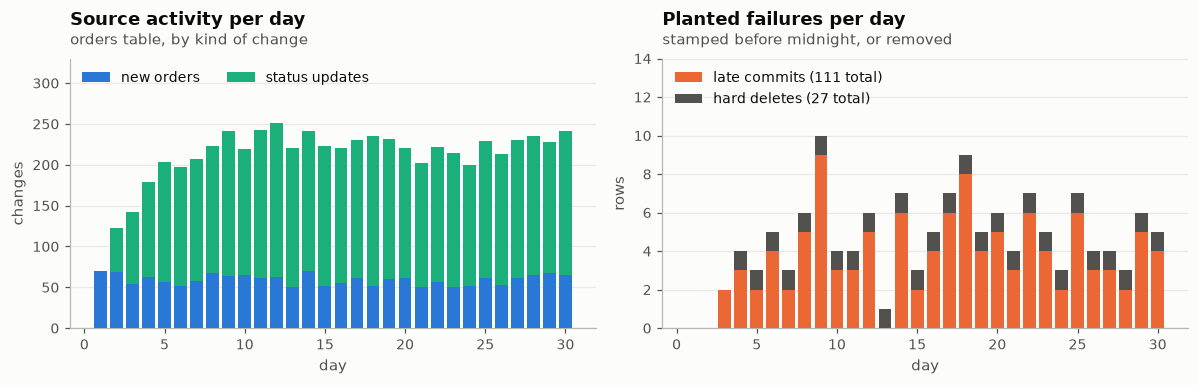

In [19]:
# ============================================================================
# 4.1  Generate the shop and show the planted failures
# ----------------------------------------------------------------------------
# In   : CFG
# Out  : days, ANSWER_KEY, chart
# Note : 30 days of OLTP activity with late commits and hard deletes at
#        counted sizes.
# ============================================================================
days, ANSWER_KEY = generate_world(CFG)
planted = planted_summary(ANSWER_KEY)
shop = Shop(":memory:", days)
shop.advance_to(CFG["source"]["days"])
print("rows at the end of day 30:", shop.counts())
print("planted:", planted)

day_n = [b["day"] for b in days]
by_op = lambda op: [sum(1 for e in b["events"] if e["op"] == op) for b in days]
late = [sum(1 for e in b["events"] if e["late"]) for b in days]
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].bar(day_n, by_op("insert_order"), color=BLUE, label="new orders", zorder=3)
ax[0].bar(day_n, by_op("update_order"), bottom=by_op("insert_order"), color=AQUA,
          label="status updates", zorder=3)
style(ax[0], "Source activity per day", "orders table, by kind of change", "day", "changes",
      money=False)
ax[0].set_ylim(0, 330)
ax[0].legend(loc="upper left", ncol=2)
ax[1].bar(day_n, late, color=ORANGE, label=f"late commits ({planted['late_commits']} total)", zorder=3)
ax[1].bar(day_n, by_op("delete_order"), bottom=late, color=INK2,
          label=f"hard deletes ({planted['hard_deletes']} total)", zorder=3)
style(ax[1], "Planted failures per day", "stamped before midnight, or removed", "day", "rows",
      money=False)
ax[1].set_ylim(0, 14)
ax[1].legend(loc="upper left")
plt.tight_layout()
plt.show()

In [20]:
# ============================================================================
# 4.2  Run the correct pipeline for 30 days
# ----------------------------------------------------------------------------
# In   : days, CFG
# Out  : correct (finished Scenario)
# Note : One DAG run per logical date, with one transient failure on the
#        retry demo date.
# ============================================================================
OPTS = PipelineOptions.from_cfg(CFG)
demo = CFG["demo"]
correct = Scenario(CFG, days, OPTS)
retry_run = None
for day in range(1, CFG["source"]["days"] + 1):
    iso = correct.date_of(day).isoformat()
    faults = ({demo["transient_task"]: demo["transient_failures"]}
              if iso == demo["transient_date"] else None)
    run = correct.run_day(day, faults=faults)
    assert run.ok, f"day {day} failed"
    if faults:
        retry_run = run
print("30 daily runs ok")
print("published revenue", usd(correct.wh.published_revenue()))
print(pd.DataFrame(correct.wh.checksums().items(), columns=["table", "sha256"]).assign(
    sha256=lambda d: d.sha256.str[:12]).to_string(index=False))

30 daily runs ok
published revenue $519,494.81
            table       sha256
dim_customer_scd2 0cfb553934b6
        fct_order 761830a3234f
   fct_order_line bc11e8e41394


In [21]:
# ============================================================================
# 4.3  Score every published day
# ----------------------------------------------------------------------------
# In   : correct, ANSWER_KEY
# Out  : per-day comparison table
# Note : Published revenue by order date and region against the truth, after
#        each run.
# ============================================================================
rows = []
for day, published in sorted(correct.published_by_day.items()):
    s = score_revenue(ANSWER_KEY, published, day)
    rows.append({"day": day, "true revenue": usd(s["truth_cents"]),
                 "published": usd(s["published_cents"]), "cells wrong": s["cells_wrong"]})
scores = pd.DataFrame(rows)
print(scores.tail(6).to_string(index=False))
print("days that match the truth exactly:", int((scores["cells wrong"] == 0).sum()), "of", len(scores))
print(score_orders(ANSWER_KEY, correct.wh, 30))
print(score_dimension(ANSWER_KEY, correct.wh, 30))

 day true revenue   published  cells wrong
  25  $427,300.55 $427,300.55            0
  26  $446,101.62 $446,101.62            0
  27  $464,759.01 $464,759.01            0
  28  $479,813.51 $479,813.51            0
  29  $499,768.64 $499,768.64            0
  30  $519,494.81 $519,494.81            0
days that match the truth exactly: 30 of 30
{'orders_true': 1762, 'fct_rows': 1762, 'orders_missing': 0, 'deleted_still_published': 0, 'status_stale': 0, 'region_wrong': 0, 'duplicate_rows': 0}
{'truth_rows': 567, 'published_rows': 567, 'exact': True}


In [22]:
# ============================================================================
# 4.4  The retried task in the runs table
# ----------------------------------------------------------------------------
# In   : retry_run
# Out  : ops.runs for that run
# Note : extract_orders failed once, was retried, and downstream tasks never
#        noticed.
# ============================================================================
print(retry_run.run_id)
print(pd.DataFrame(correct.wh.runs(retry_run.run_id),
                   columns=["run_id", "seq", "task", "status", "attempts", "error"])
      .drop(columns="run_id").to_string(index=False))

2025-06-05#1
 seq                  task  status  attempts error
   1        extract_orders success         2      
   2     extract_customers success         1      
   3              land_raw success         1      
   4             check_raw success         1      
   5         prepare_build success         1      
   6            stg_orders success         1      
   7       stg_order_lines success         1      
   8 stg_customer_versions success         1      
   9     dim_customer_scd2 success         1      
  10       plan_partitions success         1      
  11             fct_order success         1      
  12        fct_order_line success         1      
  13           check_marts success         1      
  14               publish success         1      


### 4.2 The three properties

Each is a function that runs the pipeline and returns what it measured.

In [23]:
# ============================================================================
# 4.5  Property 1, rerun
# ----------------------------------------------------------------------------
# In   : days, CFG
# Out  : rerun result
# Note : Run one date twice. Every table checksum and the raw partition
#        digest stay the same.
# ============================================================================
rerun_result = rerun(CFG, days, OPTS, None, demo["rerun_date"])
print("run ids:", rerun_result["run_ids"])
print(pd.DataFrame({
    "first run": {**{"fct_order rows": rerun_result["first"]["fct_rows"],
                     "raw partition": rerun_result["first"]["raw_orders_digest"][:12]},
                  **{k: v[:12] for k, v in rerun_result["first"]["checksums"].items()}},
    "second run": {**{"fct_order rows": rerun_result["second"]["fct_rows"],
                      "raw partition": rerun_result["second"]["raw_orders_digest"][:12]},
                   **{k: v[:12] for k, v in rerun_result["second"]["checksums"].items()}},
}).to_string())
print("identical:", rerun_result["identical"])

run ids: ['2025-06-16#1', '2025-06-16#2']
                      first run    second run
fct_order rows              904           904
raw partition      bc70f3fd722a  bc70f3fd722a
dim_customer_scd2  185c592dea3b  185c592dea3b
fct_order          10fb506fab99  10fb506fab99
fct_order_line     af8198023727  af8198023727
identical: True


In [24]:
# ============================================================================
# 4.6  Property 2, backfill
# ----------------------------------------------------------------------------
# In   : days, CFG
# Out  : backfill result
# Note : Run past dates late, with the wall clock far in the future.
# ============================================================================
backfill_result = backfill(CFG, days, OPTS, None, demo["backfill_start"], demo["backfill_end"])
print(pd.DataFrame(backfill_result["partitions"]).to_string(index=False))
print("partitions in the lake:", len(backfill_result["partition_dates"]),
      "| dated by the wall clock:", backfill_result["stray"])
print("final tables equal a clean single pass:", backfill_result["equals_clean_pass"])

 partition  rows      min_updated_at      max_updated_at  inside_own_window
2025-06-10   254 2025-06-09 21:24:05 2025-06-10 23:58:54               True
2025-06-11   236 2025-06-10 21:21:47 2025-06-11 23:57:37               True
2025-06-12   257 2025-06-11 21:16:39 2025-06-12 23:53:04               True
2025-06-13   268 2025-06-12 21:24:23 2025-06-13 23:59:05               True
2025-06-14   235 2025-06-13 21:02:28 2025-06-14 23:59:49               True
partitions in the lake: 30 | dated by the wall clock: []
final tables equal a clean single pass: True


In [25]:
# ============================================================================
# 4.7  Property 3, a break stops the run before publish
# ----------------------------------------------------------------------------
# In   : days, CFG
# Out  : break results
# Note : Rename, nulls and volume each fail at check_raw, skip publish,
#        leave published untouched.
# ============================================================================
break_results = {kind: break_demo(CFG, days, OPTS, None, kind, demo["break_date"])
                 for kind in ("rename", "nulls", "volume")}
print(pd.DataFrame([{
    "break": kind, "failed task": r["failed_task"],
    "failed check": r["failed_checks"][0][1], "tasks skipped": len(r["skipped"]),
    "published before": usd(r["published_revenue_before"]),
    "published after": usd(r["published_revenue_after"]),
    "unchanged": r["published_unchanged"],
    "rerun after fix equals clean": r["rerun_equals_clean_pass"]}
    for kind, r in break_results.items()]).to_string(index=False))
print(break_results["nulls"]["failed_checks"][0][2])

 break failed task    failed check  tasks skipped published before published after  unchanged  rerun after fix equals clean
rename   check_raw contract_orders             10      $324,213.01     $324,213.01       True                          True
 nulls   check_raw    nulls_orders             10      $324,213.01     $324,213.01       True                          True
volume   check_raw          volume             10      $324,213.01     $324,213.01       True                          True
null rate above 0.01: {'customer_id': 0.344}


---
## 5. The naive variants

Each variant is the correct pipeline with one switch changed, measured against
the same shop. Naive runs log their check failures but publish anyway, which is
what a pipeline with a separate quality report does.

In [26]:
# ============================================================================
# 5.1  Measure every naive variant
# ----------------------------------------------------------------------------
# In   : days, ANSWER_KEY, correct
# Out  : RESULTS
# Note : About two minutes. Six comparisons, each against the same shop.
# ============================================================================
t0 = time.perf_counter()
RESULTS = run_all(CFG, days, ANSWER_KEY, correct)
print(f"measured six comparisons in {time.perf_counter() - t0:.0f} s (hardware dependent)")

measured six comparisons in 133 s (hardware dependent)


                                strict watermark lookback + dedup
late commit rows planted                     111              111
late commit rows landed                        0              111
orders missing after day 30                    1                0
orders with a stale status                    25                0
orders in the wrong region                     9                0
days with exact revenue (of 30)                7               30
abs revenue error on day 30            $3,366.16            $0.00
strict extract with gating checks stops on day 3 at check_marts: ['reconcile_by_date', 'reconcile_order_count', 'reconcile_revenue']


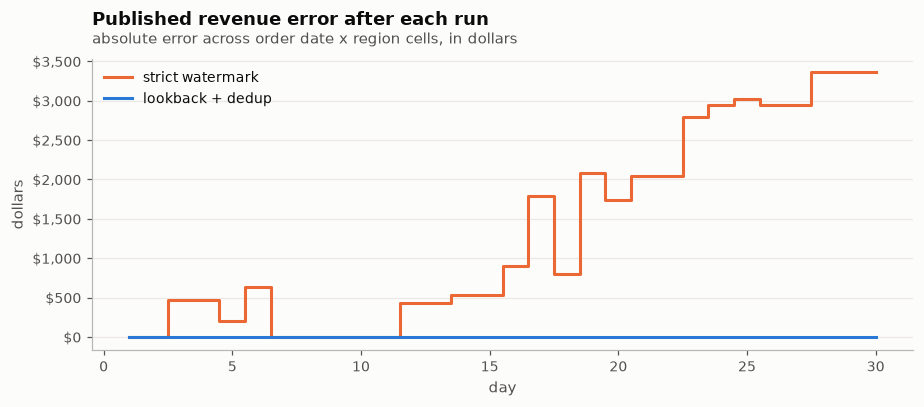

In [27]:
# ============================================================================
# 5.2  Late commits, strict watermark against lookback
# ----------------------------------------------------------------------------
# In   : RESULTS
# Out  : table and chart
# Note : Rows the strict extract misses, and how wrong the numbers are on
#        each day.
# ============================================================================
lc = RESULTS["late_commits"]
print(pd.DataFrame({
    "strict watermark": {
        "late commit rows planted": lc["strict"]["late"]["planted"],
        "late commit rows landed": lc["strict"]["late"]["landed"],
        "orders missing after day 30": lc["strict"]["orders"]["orders_missing"],
        "orders with a stale status": lc["strict"]["orders"]["status_stale"],
        "orders in the wrong region": lc["strict"]["orders"]["region_wrong"],
        "days with exact revenue (of 30)": lc["strict"]["every_day"]["days_exact"],
        "abs revenue error on day 30": usd(lc["strict"]["revenue"]["abs_error_cents"])},
    "lookback + dedup": {
        "late commit rows planted": lc["lookback"]["late"]["planted"],
        "late commit rows landed": lc["lookback"]["late"]["landed"],
        "orders missing after day 30": lc["lookback"]["orders"]["orders_missing"],
        "orders with a stale status": lc["lookback"]["orders"]["status_stale"],
        "orders in the wrong region": lc["lookback"]["orders"]["region_wrong"],
        "days with exact revenue (of 30)": lc["lookback"]["every_day"]["days_exact"],
        "abs revenue error on day 30": usd(lc["lookback"]["revenue"]["abs_error_cents"])},
}).to_string())
sg = lc["strict_gated"]
print(f"strict extract with gating checks stops on day {sg['day']} at {sg['failed_task']}:",
      sg["failed_checks"])

fig, ax = plt.subplots(figsize=(8.5, 3.8))
x = range(1, 31)
ax.step(x, [c / 100 for c in lc["strict"]["every_day"]["abs_error_cents_by_day"]],
        where="mid", color=ORANGE, label="strict watermark", zorder=3)
ax.step(x, [c / 100 for c in lc["lookback"]["every_day"]["abs_error_cents_by_day"]],
        where="mid", color=BLUE, label="lookback + dedup", zorder=4)
style(ax, "Published revenue error after each run",
      "absolute error across order date x region cells, in dollars", "day", "dollars")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

                               no_detection   reconciled
deleted orders still published           27            0
published revenue               $527,238.96  $519,494.81
true revenue                    $519,494.81  $519,494.81
revenue overstated                $7,744.15        $0.00


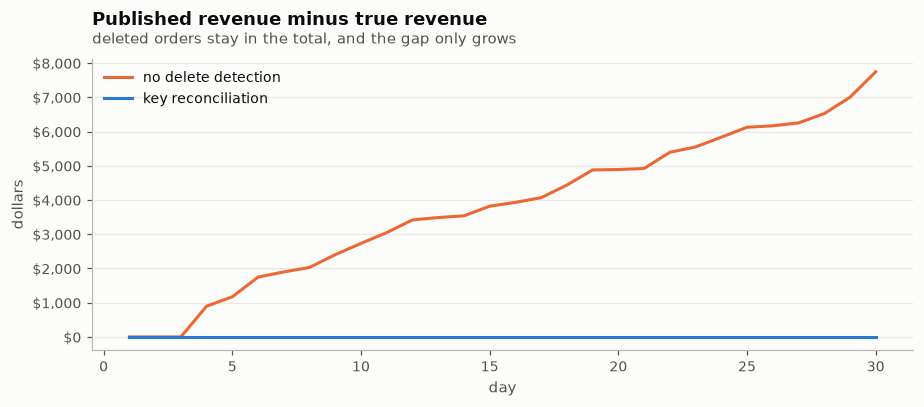

In [28]:
# ============================================================================
# 5.3  Hard deletes, with and without key reconciliation
# ----------------------------------------------------------------------------
# In   : RESULTS
# Out  : table and chart
# Note : A watermark cannot see a deletion. The published revenue drifts
#        upward.
# ============================================================================
hd = RESULTS["hard_deletes"]
print(pd.DataFrame({name: {
    "deleted orders still published": r["orders"]["deleted_still_published"],
    "published revenue": usd(r["revenue"]["published_cents"]),
    "true revenue": usd(r["revenue"]["truth_cents"]),
    "revenue overstated": usd(r["revenue"]["published_cents"] - r["revenue"]["truth_cents"])}
    for name, r in hd.items()}).to_string())

fig, ax = plt.subplots(figsize=(8.5, 3.8))
ax.plot(x, [c / 100 for c in hd["no_detection"]["every_day"]["total_error_cents_by_day"]],
        color=ORANGE, label="no delete detection", zorder=3)
ax.plot(x, [c / 100 for c in hd["reconciled"]["every_day"]["total_error_cents_by_day"]],
        color=BLUE, label="key reconciliation", zorder=4)
style(ax, "Published revenue minus true revenue",
      "deleted orders stay in the total, and the gap only grows", "day", "dollars")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

                                             append    overwrite
rows added by running day 15 twice              249            0
revenue double counted by that rerun     $58,078.27        $0.00
fct_order rows after day 30                    7027         1762
true orders                                    1762         1762
duplicate rows                                 5238            0
published revenue                     $1,647,637.43  $519,494.81


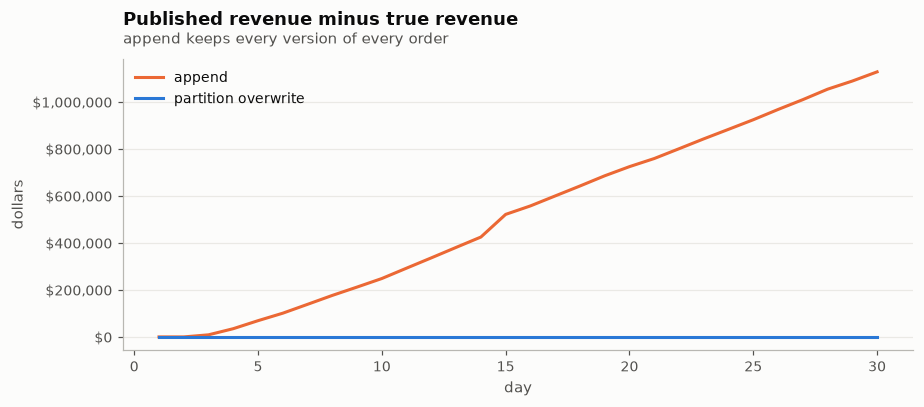

In [29]:
# ============================================================================
# 5.4  Append against partition overwrite
# ----------------------------------------------------------------------------
# In   : RESULTS
# Out  : table and chart
# Note : Run one date twice. Append double counts it.
# ============================================================================
ao = RESULTS["append_vs_overwrite"]
print(pd.DataFrame({name: {
    f"rows added by running day {r['rerun_day']} twice": r["rows_added_by_rerun"],
    "revenue double counted by that rerun": usd(r["revenue_added_by_rerun"]),
    "fct_order rows after day 30": r["orders"]["fct_rows"],
    "true orders": r["orders"]["orders_true"],
    "duplicate rows": r["orders"]["duplicate_rows"],
    "published revenue": usd(r["revenue"]["published_cents"])}
    for name, r in ao.items()}).to_string())

fig, ax = plt.subplots(figsize=(8.5, 3.8))
ax.plot(x, [c / 100 for c in ao["append"]["every_day"]["total_error_cents_by_day"]],
        color=ORANGE, label="append", zorder=3)
ax.plot(x, [c / 100 for c in ao["overwrite"]["every_day"]["total_error_cents_by_day"]],
        color=BLUE, label="partition overwrite", zorder=4)
style(ax, "Published revenue minus true revenue",
      "append keeps every version of every order", "day", "dollars")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

past days backfilled                                 5
their own partitions present                         0
rows in stray partition 2025-07-15                 235
orders missing right after the backfill            114
orders with a stale status right after             230
orders missing after day 30                       1014
published revenue after day 30             $229,234.04
true revenue                               $519,494.81


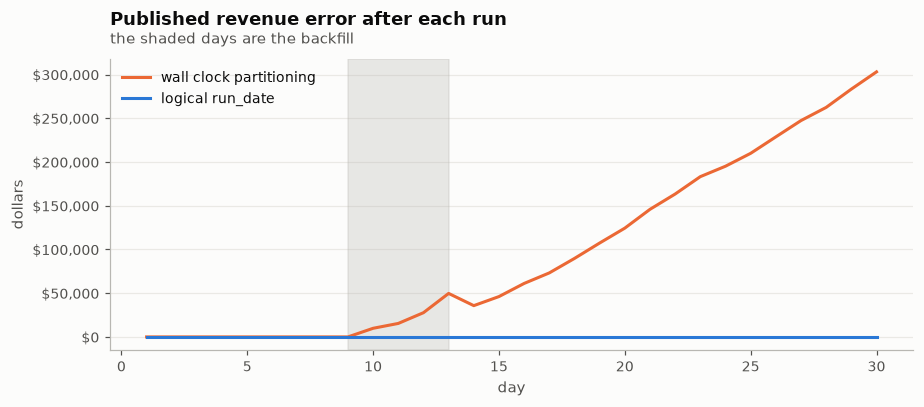

In [30]:
# ============================================================================
# 5.5  Wall clock against the logical run_date
# ----------------------------------------------------------------------------
# In   : RESULTS
# Out  : table and chart
# Note : A task that files data under today's date loses the days it
#        backfills.
# ============================================================================
wc = RESULTS["wall_clock"]
print(pd.Series({
    "past days backfilled": wc["days_backfilled"],
    "their own partitions present": wc["partitions_present"],
    f"rows in stray partition {wc['stray_partition']}": wc["rows_in_stray_partition"],
    "orders missing right after the backfill": wc["after_backfill"]["orders"]["orders_missing"],
    "orders with a stale status right after": wc["after_backfill"]["orders"]["status_stale"],
    "orders missing after day 30": wc["orders"]["orders_missing"],
    "published revenue after day 30": usd(wc["revenue"]["published_cents"]),
    "true revenue": usd(wc["revenue"]["truth_cents"])}).to_string())

fig, ax = plt.subplots(figsize=(8.5, 3.8))
ax.plot(x, [c / 100 for c in wc["every_day"]["abs_error_cents_by_day"]], color=ORANGE,
        label="wall clock partitioning", zorder=3)
ax.plot(x, [c / 100 for c in ao["overwrite"]["every_day"]["abs_error_cents_by_day"]],
        color=BLUE, label="logical run_date", zorder=4)
ax.axvspan(9, 13, color=MUTED, alpha=0.3, zorder=1)
style(ax, "Published revenue error after each run",
      "the shaded days are the backfill", "day", "dollars")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

 break check that fires published before published, report only abs error, report only revenue with no region published, gated          gated run
rename  contract_orders      $324,213.01            $291,367.39             $50,390.55                  $0.00      $324,213.01 stops at check_raw
 nulls     nulls_orders      $324,213.01            $341,757.94             $39,996.22             $19,998.11      $324,213.01 stops at check_raw
volume           volume      $324,213.01            $325,722.62             $16,059.52                  $0.00      $324,213.01 stops at check_raw


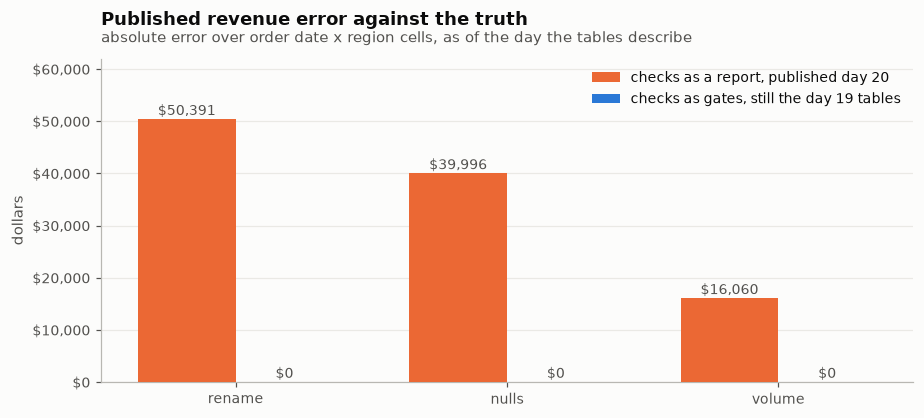

In [31]:
# ============================================================================
# 5.6  Checks as a report against checks as gates
# ----------------------------------------------------------------------------
# In   : RESULTS
# Out  : table and chart
# Note : The report publishes the bad day. The gate leaves the last good
#        tables in place.
# ============================================================================
br = RESULTS["breaks"]
print(pd.DataFrame([{
    "break": kind, "check that fires": br[kind]["gate"]["first_failed_check"],
    "published before": usd(br[kind]["report"]["published_before"]),
    "published, report only": usd(br[kind]["report"]["published_after"]),
    "abs error, report only": usd(br[kind]["report"]["error_cents"]),
    "revenue with no region": usd(br[kind]["report"]["no_region_cents"]),
    "published, gated": usd(br[kind]["gate"]["published_after"]),
    "gated run": "stops at " + br[kind]["gate"]["failed_task"]}
    for kind in br]).to_string(index=False))

fig, ax = plt.subplots(figsize=(8.5, 3.9))
kinds = list(br)
pos = list(range(len(kinds)))
w = 0.36
report_err = [br[k]["report"]["error_cents"] / 100 for k in kinds]
gate_err = [br[k]["gate"]["error_vs_day_before_cents"] / 100 for k in kinds]
ax.bar([p - w / 2 for p in pos], report_err, w, color=ORANGE,
       label="checks as a report, published day 20", zorder=3)
ax.bar([p + w / 2 for p in pos], gate_err, w, color=BLUE,
       label="checks as gates, still the day 19 tables", zorder=3)
for p, v in zip(pos, report_err):
    ax.text(p - w / 2, v + 800, f"${v:,.0f}", ha="center", fontsize=9, color=INK2)
for p, v in zip(pos, gate_err):
    ax.text(p + w / 2, v + 800, f"${v:,.0f}", ha="center", fontsize=9, color=INK2)
ax.set_xticks(pos)
ax.set_xticklabels(kinds)
ax.set_ylim(0, 62000)
style(ax, "Published revenue error against the truth",
      "absolute error over order date x region cells, as of the day the tables describe",
      "", "dollars")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

                                     type1  type2
orders in the wrong region             218      0
date x region cells wrong               99      0
abs revenue error across cells  $55,522.66  $0.00
total revenue error                  $0.00  $0.00


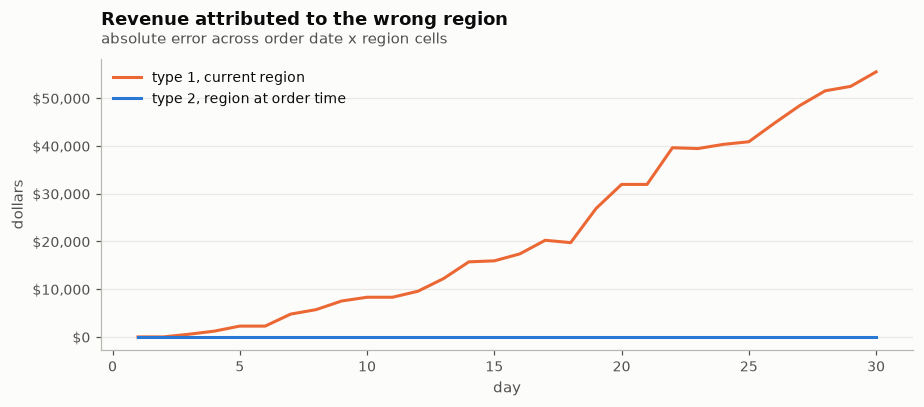

In [32]:
# ============================================================================
# 5.7  Region at order time against current region
# ----------------------------------------------------------------------------
# In   : RESULTS
# Out  : table and chart
# Note : SCD type 1 moves revenue between regions without changing the
#        total.
# ============================================================================
sd = RESULTS["scd_type"]
print(pd.DataFrame({name: {
    "orders in the wrong region": r["orders"]["region_wrong"],
    "date x region cells wrong": r["revenue"]["cells_wrong"],
    "abs revenue error across cells": usd(r["revenue"]["abs_error_cents"]),
    "total revenue error": usd(r["revenue"]["published_cents"] - r["revenue"]["truth_cents"])}
    for name, r in sd.items()}).to_string())

fig, ax = plt.subplots(figsize=(8.5, 3.8))
ax.plot(x, [c / 100 for c in sd["type1"]["every_day"]["abs_error_cents_by_day"]],
        color=ORANGE, label="type 1, current region", zorder=3)
ax.plot(x, [c / 100 for c in sd["type2"]["every_day"]["abs_error_cents_by_day"]],
        color=BLUE, label="type 2, region at order time", zorder=4)
style(ax, "Revenue attributed to the wrong region",
      "absolute error across order date x region cells", "day", "dollars")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

In [33]:
# ============================================================================
# 6.1  Every headline number as one JSON line
# ----------------------------------------------------------------------------
# In   : RESULTS, correct
# Out  : NOTEBOOK_RESULTS
# Note : The repo's test suite compares this line with what run.py produces.
# ============================================================================
headline = {
    "naive": RESULTS,
    "clean_checksums": correct.wh.checksums(),
    "rerun": {"identical": rerun_result["identical"], "checksums": rerun_result["first"]["checksums"]},
    "backfill": {"equals_clean_pass": backfill_result["equals_clean_pass"],
                 "rows": [p["rows"] for p in backfill_result["partitions"]]},
    "breaks": {k: {"failed_task": r["failed_task"], "check": r["failed_checks"][0][1],
                   "unchanged": r["published_unchanged"]} for k, r in break_results.items()},
}
print("NOTEBOOK_RESULTS " + json.dumps(headline, sort_keys=True, default=str))

NOTEBOOK_RESULTS {"backfill": {"equals_clean_pass": true, "rows": [254, 236, 257, 268, 235]}, "breaks": {"nulls": {"check": "nulls_orders", "failed_task": "check_raw", "unchanged": true}, "rename": {"check": "contract_orders", "failed_task": "check_raw", "unchanged": true}, "volume": {"check": "volume", "failed_task": "check_raw", "unchanged": true}}, "clean_checksums": {"dim_customer_scd2": "0cfb553934b6adbcfe56b5416eb72f0ccc13ff90b2d69c2d26f76ffe3c0e1983", "fct_order": "761830a3234fae2c3150a485faab4893da768ca3e960657a8355f7e8eedda721", "fct_order_line": "bc11e8e41394045345a3f638aa97bd3e16845f0914b4f5f51a58b14576ba7155"}, "naive": {"append_vs_overwrite": {"append": {"every_day": {"abs_error_cents_by_day": [0, 0, 891162, 3504848, 6914201, 10098973, 13869947, 17667741, 21221225, 24856452, 29277645, 33659933, 38103632, 42511826, 52151467, 55760533, 60003619, 64231757, 68577087, 72474864, 75923901, 80089224, 84302123, 88351319, 92436696, 96800684, 100987756, 105437709, 108908903, 11281426

---
## What this notebook does not prove

* The source is a simulation with a replayable history. A real OLTP table keeps
  only current rows, so a real backfill sees the latest version of each row and
  not every intermediate state.
* Lateness is bounded by `source.late_max_minutes`. A commit later than the
  lookback window is missed, and the reconciliation check is what would catch it.
* The data is small, and the staging models are rebuilt from all raw partitions
  on each run. At scale that step becomes incremental too.
* One process runs one task at a time. The DAG runner does not parallelise.